In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

# Miscelleanous

## Median plot Donatelo 3 + 5a

['Doxy-1' 'Doxy-2' 'Doxy-3' 'Doxy-4' 'Doxy-5' 'YPD']


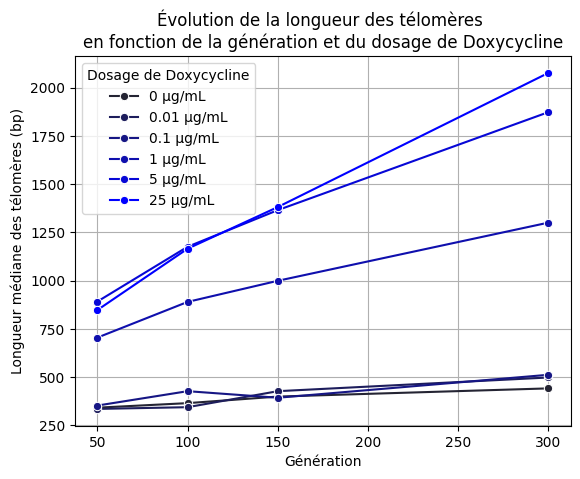

In [110]:
files_to_get = [
    "../../results/G50_YPD/G50_YPD_Filtred_Results.csv",
    "../../results/G50_Doxy-1/G50_Doxy-1_Filtred_Results.csv",
    "../../results/G50_Doxy-2/G50_Doxy-2_Filtred_Results.csv",
    "../../results/G50_Doxy-3/G50_Doxy-3_Filtred_Results.csv",
    "../../results/G50_Doxy-4/G50_Doxy-4_Filtred_Results.csv",
    "../../results/G50_Doxy-5/G50_Doxy-5_Filtred_Results.csv",
    "../../results/G100_YPD/G100_YPD_Filtred_Results.csv",
    "../../results/G100_Doxy-1/G100_Doxy-1_Filtred_Results.csv",
    "../../results/G100_Doxy-2/G100_Doxy-2_Filtred_Results.csv",
    "../../results/G100_Doxy-3/G100_Doxy-3_Filtred_Results.csv",
    "../../results/G100_Doxy-4/G100_Doxy-4_Filtred_Results.csv",
    "../../results/G100_Doxy-5/G100_Doxy-5_Filtred_Results.csv",
    "../../results/G150_YPD/G150_YPD_Filtred_Results.csv",
    "../../results/G150_Doxy-1/G150_Doxy-1_Filtred_Results.csv",
    "../../results/G150_Doxy-2/G150_Doxy-2_Filtred_Results.csv",
    "../../results/G150_Doxy-3/G150_Doxy-3_Filtred_Results.csv",
    "../../results/G150_Doxy-4/G150_Doxy-4_Filtred_Results.csv",
    "../../results/G150_Doxy-5/G150_Doxy-5_Filtred_Results.csv",
    "../../results/G300_YPD/G300_YPD_Filtred_Results.csv",
    "../../results/G300_Doxy-1/G300_Doxy-1_Filtred_Results.csv",
    "../../results/G300_Doxy-2/G300_Doxy-2_Filtred_Results.csv",
    "../../results/G300_Doxy-3/G300_Doxy-3_Filtred_Results.csv",
    "../../results/G300_Doxy-4/G300_Doxy-4_Filtred_Results.csv",
    "../../results/G300_Doxy-5/G300_Doxy-5_Filtred_Results.csv",
]

data = pd.DataFrame()

for path in files_to_get:
    df = pd.read_csv(path, sep = "\t")
    df = df[["assembly", "len"]]
    data = pd.concat([data, df], ignore_index=True) if 'data' in locals() else df

data = data.groupby("assembly")["len"].median().reset_index()
data["generation"] = data["assembly"].str.split("_").str[0].str.extract('(\d+)').astype(int)
data["Group"] = data["assembly"].str.split("_").str[1]

print(data["Group"].unique())

group_name = {
    "YPD": "0 µg/mL",
    "Doxy-1": "0.01 µg/mL",
    "Doxy-2": "0.1 µg/mL",
    "Doxy-3": "1 µg/mL",
    "Doxy-4": "5 µg/mL",
    "Doxy-5": "25 µg/mL",
    "25": "25 µg/mL",
}

data["Group"] = data["Group"].map(group_name)

sns.lineplot(data = data, 
             x="generation", 
             y="len", 
             hue="Group", 
             marker="o", 
             hue_order = ["0 µg/mL", "0.01 µg/mL", "0.1 µg/mL", "1 µg/mL", "5 µg/mL", "25 µg/mL"],
             palette = "dark:blue"
             )
plt.xlabel("Génération")
plt.ylabel("Longueur médiane des télomères (bp)")
plt.title("Évolution de la longueur des télomères \nen fonction de la génération et du dosage de Doxycycline")
plt.legend(title="Dosage de Doxycycline")
plt.grid()
plt.savefig("donatelo3_telomere_length_evolution.png", dpi=450)

## Median plot Donatelo 4

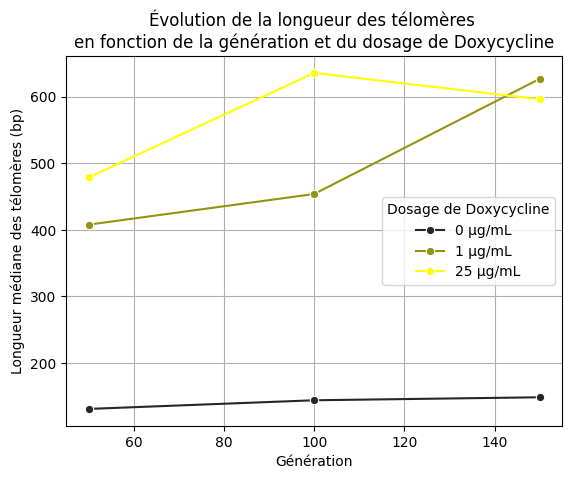

In [121]:
base_dir = "../../results/"
files_to_get = ["G50_YPD-Only/G50_YPD-Only_Filtred_Results.csv", "G100_YPD-Only/G100_YPD-Only_Filtred_Results.csv", "G150_YPD-Only/G150_YPD-Only_Filtred_Results.csv", "G50_1_DOXY/G50_1_DOXY_Filtred_Results.csv", "G100_1_DOXY/G100_1_DOXY_Filtred_Results.csv", "G150_1_DOXY/G150_1_DOXY_Filtred_Results.csv", 
"G50_25_DOXY/G50_25_DOXY_Filtred_Results.csv", "G100_25_DOXY/G100_25_DOXY_Filtred_Results.csv", "G150_25_DOXY/G150_25_DOXY_Filtred_Results.csv"]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

data = pd.DataFrame()

for path in full_paths:
    df = pd.read_csv(path, sep = "\t")
    df = df[["assembly", "len"]]
    data = pd.concat([data, df], ignore_index=True) if 'data' in locals() else df

data = data.groupby("assembly")["len"].median().reset_index()
data["generation"] = data["assembly"].str.split("_").str[0].str.extract('(\d+)').astype(int)
data["Group"] = data["assembly"].str.split("_").str[1]

group_name = {
    "YPD-Only": "0 µg/mL",
    "1": "1 µg/mL",
    "25": "25 µg/mL",
}

data["Group"] = data["Group"].map(group_name)

sns.lineplot(data = data, 
             x="generation", 
             y="len", 
             hue="Group", 
             marker="o", 
             palette = "dark:yellow",
             hue_order = ["0 µg/mL", "1 µg/mL", "25 µg/mL"]
             )
plt.xlabel("Génération")
plt.ylabel("Longueur médiane des télomères (bp)")
plt.title("Évolution de la longueur des télomères \nen fonction de la génération et du dosage de Doxycycline")
plt.legend(title="Dosage de Doxycycline")
plt.grid()
plt.savefig("donatelo4_telomere_length_evolution.png", dpi=450)

![Alt text](../../median_plot.png)

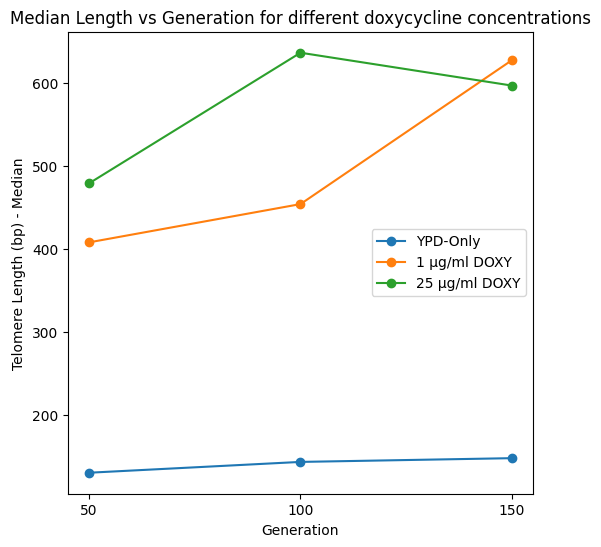

In [111]:
base_dir = "../../results/"
files_to_get = ["G50_YPD-Only/G50_YPD-Only_Filtred_Results.csv", "G100_YPD-Only/G100_YPD-Only_Filtred_Results.csv", "G150_YPD-Only/G150_YPD-Only_Filtred_Results.csv", "G50_1_DOXY/G50_1_DOXY_Filtred_Results.csv", "G100_1_DOXY/G100_1_DOXY_Filtred_Results.csv", "G150_1_DOXY/G150_1_DOXY_Filtred_Results.csv", 
"G50_25_DOXY/G50_25_DOXY_Filtred_Results.csv", "G100_25_DOXY/G100_25_DOXY_Filtred_Results.csv", "G150_25_DOXY/G150_25_DOXY_Filtred_Results.csv"]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

YPD_data_list = []
DOXY1_data_list = []
DOXY25_data_list = []

for index, path in enumerate(full_paths):
    if index < 3:
        data = pd.read_csv(path, sep="\t")
        YPD_data_list.append(data["len"].median())
    elif index < 6:
        data = pd.read_csv(path, sep="\t")
        DOXY1_data_list.append(data["len"].median())
    else:
        data = pd.read_csv(path, sep="\t")
        DOXY25_data_list.append(data["len"].median())

plt.figure(figsize=(6, 6))
plt.plot([50, 100, 150], YPD_data_list, marker='o', label='YPD-Only')
plt.plot([50, 100, 150], DOXY1_data_list, marker='o', label='1 µg/ml DOXY')
plt.plot([50, 100, 150], DOXY25_data_list, marker='o', label='25 µg/ml DOXY')
plt.xlabel('Generation')
plt.xticks([50, 100, 150])
plt.ylabel('Telomere Length (bp) - Median')
plt.title('Median Length vs Generation for different doxycycline concentrations')
plt.legend()
#plt.savefig("donatelo4_median_length.png", dpi=450)

In [16]:
print(YPD_data_list)
print(DOXY1_data_list)
print(DOXY25_data_list)

[np.float64(131.5), np.float64(142.0), np.float64(148.5)]
[np.float64(398.5), np.float64(427.0), np.float64(631.5)]
[np.float64(479.0), np.float64(634.5), np.float64(631.0)]


In [23]:
print("YPD")
print((142-131.5)/50)
print((148.5-131.5)/100)

print("DOXY 1")
print((427-398.5)/50)
print((631.5-398.5)/100)

print("DOXY 25")
print((634-479)/50)
print((631-479)/100)

YPD
0.21
0.17
DOXY 1
0.57
2.33
DOXY 25
3.1
1.52


## Distributions

In [ ]:
base_dir = "../../results/"
files_to_get = ["G600_0.01_DOXY_Rep1/G600_0.01_DOXY_Rep1_Filtred_Results.csv", 
"G600_0.01_DOXY_Rep2/G600_0.01_DOXY_Rep2_Filtred_Results.csv", 
"G600_0.01_DOXY_Rep3/G600_0.01_DOXY_Rep3_Filtred_Results.csv", 
"G600_0.1_DOXY_Rep1/G600_0.1_DOXY_Rep1_Filtred_Results.csv", 
"G600_0.1_DOXY_Rep2/G600_0.1_DOXY_Rep2_Filtred_Results.csv", 
"G600_0.1_DOXY_Rep3/G600_0.1_DOXY_Rep3_Filtred_Results.csv", 
"G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv", 
"G600_25_DOXY_Rep2/G600_25_DOXY_Rep2_Filtred_Results.csv", 
"G600_25_DOXY_Rep3/G600_25_DOXY_Rep3_Filtred_Results.csv", 
"G600_YPD-Only_Rep1/G600_YPD-Only_Rep1_Filtred_Results.csv", 
"G600_YPD-Only_Rep2/G600_YPD-Only_Rep2_Filtred_Results.csv", 
"G600_YPD-Only_Rep3/G600_YPD-Only_Rep3_Filtred_Results.csv"]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

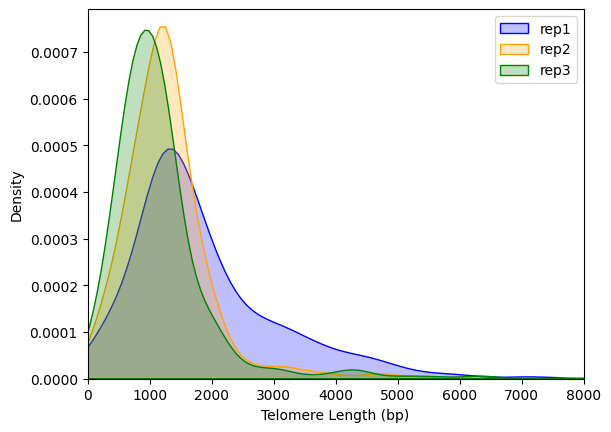

In [49]:
data_001_DOXY_rep1 = pd.read_csv(full_paths[6], sep="\t")
data_001_DOXY_rep2 = pd.read_csv(full_paths[7], sep="\t")
data_001_DOXY_rep3 = pd.read_csv(full_paths[8], sep="\t")
sns.kdeplot(data_001_DOXY_rep1["len"], fill=True, color="blue", label="rep1")
sns.kdeplot(data_001_DOXY_rep2["len"], fill=True, color="orange", label="rep2")
sns.kdeplot(data_001_DOXY_rep3["len"], fill=True, color="green", label="rep3")
plt.xlabel('Telomere Length (bp)')
plt.xlim(0, 8000)
plt.ylabel('Density')
plt.legend()
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='len', ylabel='Density'>

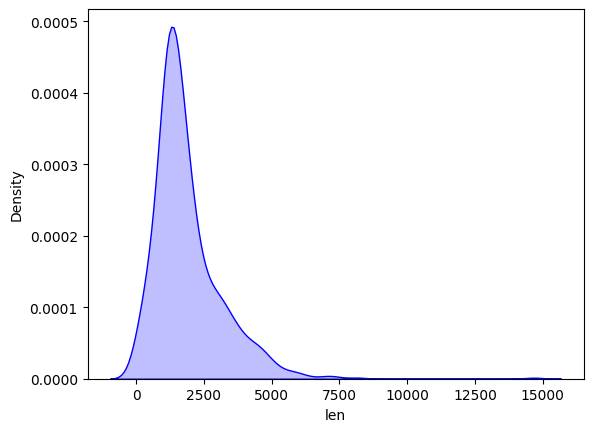

In [12]:
data_001_DOXY_rep1 = pd.read_csv("../../results/G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv", sep="\t")
sns.kdeplot(data_001_DOXY_rep1["len"], fill=True, color="blue", label="WT BY")

In [53]:
print(data_001_DOXY_rep1["len"].median())
print(data_001_DOXY_rep2["len"].median())
print(data_001_DOXY_rep3["len"].median())

1526.5
1214.0
1020.0


In [66]:
base_dir = "../../results/"
files_to_get = [
    "Y2B1115/Y2B1115_Filtred_Results.csv",
    "OS13342/OS13342_Filtred_Results.csv",
    "AG0/AG0_Filtred_Results.csv",
    "AG150/AG150_Filtred_Results.csv",
    "BG0/BG0_Filtred_Results.csv",
    "BG150/BG150_Filtred_Results.csv",
    "CG0/CG0_Filtred_Results.csv",
    "CG150/CG150_Filtred_Results.csv",
    "SRR37421626/SRR37421626_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

           Sample  Length
0         Y2B1115   413.0
1         Y2B1115   380.0
2         Y2B1115   467.0
3         Y2B1115   454.0
4         Y2B1115   434.0
...           ...     ...
9138  SRR37421626   232.0
9139  SRR37421626   237.0
9140  SRR37421626   615.0
9141  SRR37421626   272.0
9142  SRR37421626  1210.0

[4653 rows x 2 columns]


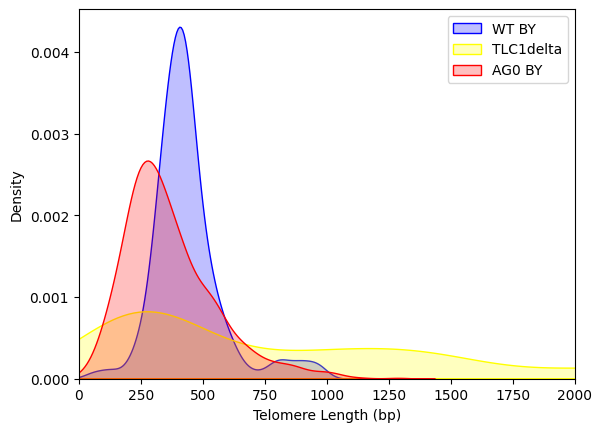

In [70]:
sns.kdeplot(data["Length"].loc[data["Sample"] == "Y2B1115"], fill=True, color="blue", label="WT BY")
sns.kdeplot(data["Length"].loc[data["Sample"] == "SRR37421626"], fill=True, color="yellow", label="TLC1delta")
sns.kdeplot(data["Length"].loc[data["Sample"] == "AG0"], fill=True, color="red", label="AG0 BY")

#sns.kdeplot(data["Length"].loc[data["Sample"] == "BG0"], fill=True, color="yellow", label="BG0 BY")
#sns.kdeplot(data["Length"].loc[data["Sample"] == "CG0"], fill=True, color="green", label="CG0 BY")

plt.xlabel('Telomere Length (bp)')
plt.xlim(0, 2000)
plt.ylabel('Density')
plt.legend()
plt.show()

levy distribution

stable distribution (not gaussian)

## Some boxplot for slides

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [6]:
base_dir = "../../results/"
files_to_get = [
    "Y2B1394/Y2B1394_Filtred_Results.csv",
    "G300_Doxy-5/G300_Doxy-5_Filtred_Results.csv",
    "G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv",
    "G600_25_DOXY_Rep2/G600_25_DOXY_Rep2_Filtred_Results.csv",
    "G600_25_DOXY_Rep3/G600_25_DOXY_Rep3_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

                 Sample  Length
0               Y2B1394   297.0
1               Y2B1394   307.0
2               Y2B1394   168.0
3               Y2B1394   181.0
4               Y2B1394   117.0
...                 ...     ...
5835  G600_25_DOXY_Rep3  1134.0
5836  G600_25_DOXY_Rep3   416.0
5837  G600_25_DOXY_Rep3   233.0
5838  G600_25_DOXY_Rep3  1212.0
5839  G600_25_DOXY_Rep3   670.0

[3887 rows x 2 columns]


In [12]:
gen_map = {
    'Y2B1394': 'G0',
    'G300_Doxy-5': 'G300',
    'G600_25_DOXY_Rep1': 'G600 Rep1',
    'G600_25_DOXY_Rep2': 'G600 Rep2',
    'G600_25_DOXY_Rep3': 'G600 Rep3'
}

data["generation"] = data['Sample'].map(gen_map)
data.head()

,Sample,Length,generation
0,Y2B1394,297.0,G0
1,Y2B1394,307.0,G0
2,Y2B1394,168.0,G0
3,Y2B1394,181.0,G0
4,Y2B1394,117.0,G0


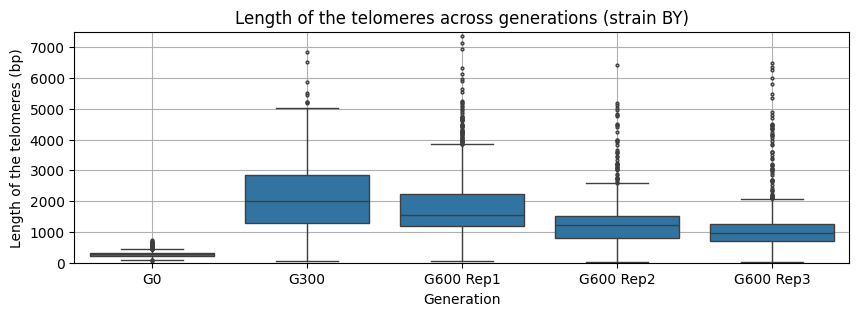

In [22]:
plt.figure(figsize = (10,3))
sns.boxplot(data=data, x="generation", y="Length", fliersize=2)
plt.ylim(0, 7500)
plt.title("Length of the telomeres across generations (strain BY)")
plt.xlabel("Generation")
plt.ylabel("Length of the telomeres (bp)")
plt.grid()

# Boxplot

## Donatelo 1

In [3]:
base_dir = "../../results/"
files_to_get = [
    "Y2B1115/Y2B1115_Filtred_Results.csv",
    "OS13342/OS13342_Filtred_Results.csv",
    "Y2B1394/Y2B1394_Filtred_Results.csv", 
    "Y2B1397/Y2B1397_Filtred_Results.csv", 
    "A10/A10_Filtred_Results.csv", 
    "B10/B10_Filtred_Results.csv", 
    "G10/G10_Filtred_Results.csv", 
    "H10/H10_Filtred_Results.csv", 
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

        Sample  Length
0      Y2B1115   413.0
1      Y2B1115   380.0
2      Y2B1115   467.0
3      Y2B1115   454.0
4      Y2B1115   434.0
...        ...     ...
13275      H10   151.0
13276      H10   220.0
13277      H10   204.0
13278      H10   193.0
13279      H10   223.0

[7036 rows x 2 columns]


In [4]:
group_map = {
    'A10': 'BY',
    'B10': 'CAS',
    'G10': 'BY',
    'H10': 'CAS',
    'Y2B1115': 'BY',
    'Y2B1394': 'BY',
    'Y2B1397': 'CAS',
    'OS13342': 'CAS'
}

gen_map = {
    'A10': 'G50',
    'B10': 'G50',
    'G10': 'G300',
    'H10': 'G300',
    'Y2B1115': 'WT',
    'Y2B1394': 'G0',
    'Y2B1397': 'G0',
    'OS13342': 'WT'
}

data['Strains'] = data['Sample'].map(group_map)
data["generation"] = data['Sample'].map(gen_map)
data.head()

,Sample,Length,Strains,generation
0,Y2B1115,413.0,BY,WT
1,Y2B1115,380.0,BY,WT
2,Y2B1115,467.0,BY,WT
3,Y2B1115,454.0,BY,WT
4,Y2B1115,434.0,BY,WT


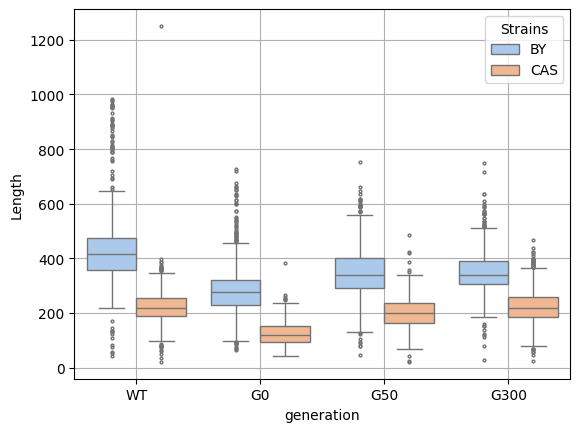

In [5]:
sns.boxplot(data=data, x="generation", y="Length", hue="Strains", palette="pastel", fliersize=2)
plt.grid()
#plt.savefig("donatelo1_tel_len.png", dpi=450)

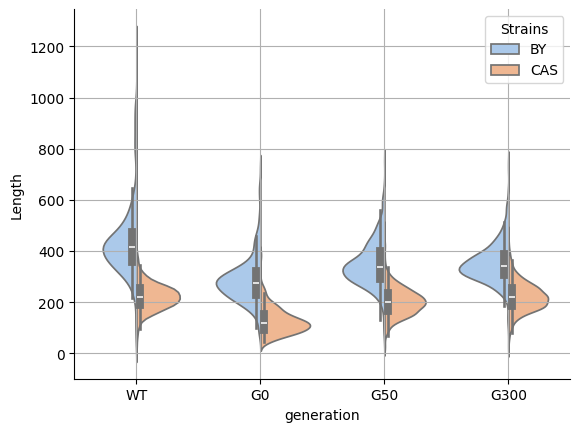

In [6]:
ax = sns.violinplot(data=data, 
                    x="generation", 
                    y="Length", 
                    hue="Strains", 
                    split=True, 
                    inner="box",
                    palette="pastel")

sns.despine()
plt.grid()

In [64]:
data.groupby("Sample")["Length"].median()

Sample
A10        339.0
B10        199.5
G10        341.0
H10        219.0
OS13342    220.0
Y2B1115    416.0
Y2B1394    277.0
Y2B1397    118.0
Name: Length, dtype: float64

In [9]:
temp_data.columns

Index(['assembly', 'chrom', 'chrom_side', 'chrom_type', 'chrom_start',
       'chrom_end', 'chrom_len', 'chrom_size', 'strain', '#reads', 'read',
       'side', 'type', 'start', 'end', 'len', 'read_size_trim', 'MAPQ',
       'FLAG'],
      dtype='object')

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

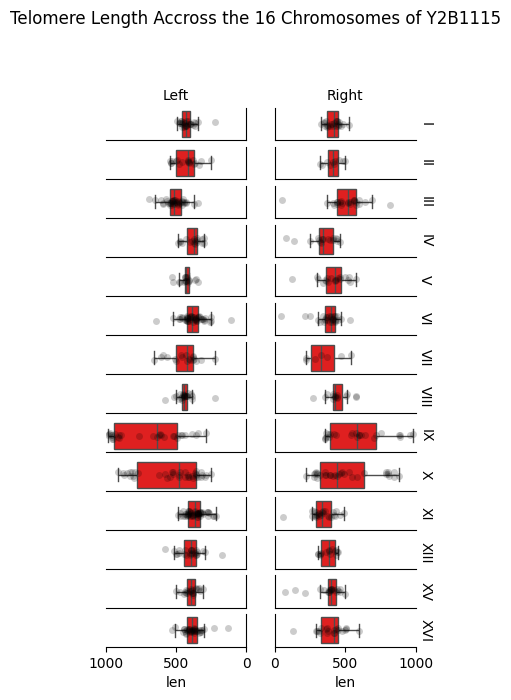

In [ ]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross the 16 Chromosomes of " + assemb, y=1.02)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="red", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, 1000)
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.show()


## Donatelo 2

In [3]:
base_dir = "../../results/"
files_to_get = [
    "AG0/AG0_Filtred_Results.csv",
    "AG50/AG50_Filtred_Results.csv",
    "AG150/AG150_Filtred_Results.csv",
    "BG0/BG0_Filtred_Results.csv",
    "BG50/BG50_Filtred_Results.csv",
    "BG150/BG150_Filtred_Results.csv",
    "CG0/CG0_Filtred_Results.csv",
    "CG50/CG50_Filtred_Results.csv",
    "CG150/CG150_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

     Sample  Length
0       AG0   223.0
1       AG0   193.0
2       AG0   714.0
3       AG0   524.0
4       AG0   492.0
...     ...     ...
6890  CG150  2844.0
6891  CG150  1541.0
6892  CG150  2280.0
6893  CG150  1041.0
6894  CG150  1224.0

[4263 rows x 2 columns]


In [4]:
group_map = {
    'AG0': 'AG',
    'AG50': 'AG',
    'AG150': 'AG',
    'BG0': 'BG',
    'BG50': 'BG',
    'BG150': 'BG',
    'CG0': 'CG',
    'CG50': 'CG',
    'CG150': 'CG'
}

data['Group'] = data['Sample'].map(group_map)
data.head()

,Sample,Length,Group
0,AG0,223.0,AG
1,AG0,193.0,AG
2,AG0,714.0,AG
3,AG0,524.0,AG
4,AG0,492.0,AG


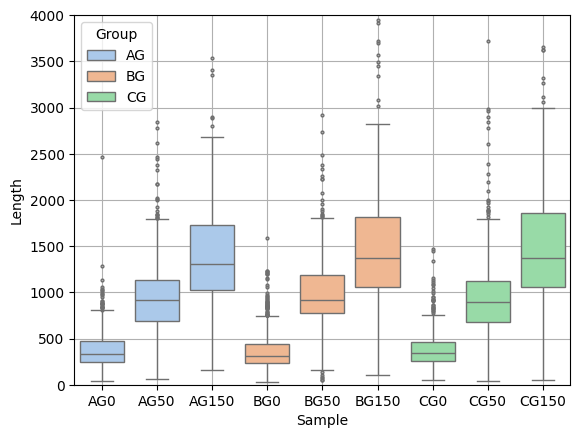

In [5]:
sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="pastel", fliersize=2)
plt.ylim(0, 4000)
plt.grid()
plt.savefig("donatelo2_tel_len.png", dpi=450)

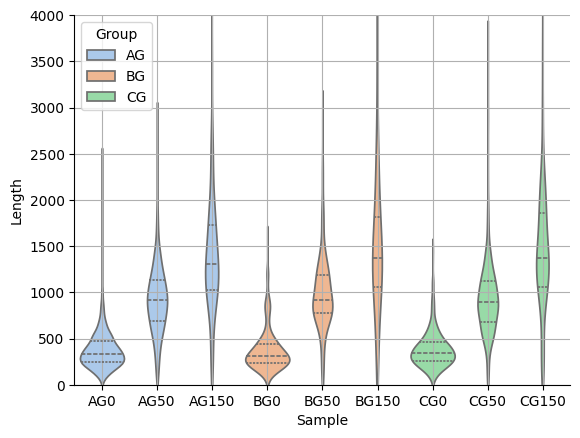

In [6]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="pastel")

sns.despine()
plt.ylim(0, 4000)
plt.grid()

In [10]:
data.groupby("Sample")["Length"].median()

Sample
AG0       337.0
AG150    1311.0
AG50      915.5
BG0       310.0
BG150    1367.0
BG50      914.0
CG0       347.0
CG150    1373.0
CG50      896.0
Name: Length, dtype: float64

## Donatelo 3

In [11]:
base_dir = "../../results/"
files_to_get = [
    "G50_YPD/G50_YPD_Filtred_Results.csv",
    "G100_YPD/G100_YPD_Filtred_Results.csv",
    "G150_YPD/G150_YPD_Filtred_Results.csv",
    "G300_YPD/G300_YPD_Filtred_Results.csv",

    "G50_Doxy-1/G50_Doxy-1_Filtred_Results.csv",
    "G100_Doxy-1/G100_Doxy-1_Filtred_Results.csv",
    "G150_Doxy-1/G150_Doxy-1_Filtred_Results.csv",
    "G300_Doxy-1/G300_Doxy-1_Filtred_Results.csv",

    "G50_Doxy-2/G50_Doxy-2_Filtred_Results.csv",
    "G100_Doxy-2/G100_Doxy-2_Filtred_Results.csv",
    "G150_Doxy-2/G150_Doxy-2_Filtred_Results.csv",
    "G300_Doxy-2/G300_Doxy-2_Filtred_Results.csv",

    "G50_Doxy-3/G50_Doxy-3_Filtred_Results.csv",
    "G100_Doxy-3/G100_Doxy-3_Filtred_Results.csv",
    "G150_Doxy-3/G150_Doxy-3_Filtred_Results.csv",
    "G300_Doxy-3/G300_Doxy-3_Filtred_Results.csv",

    "G50_Doxy-4/G50_Doxy-4_Filtred_Results.csv",
    "G100_Doxy-4/G100_Doxy-4_Filtred_Results.csv",
    "G150_Doxy-4/G150_Doxy-4_Filtred_Results.csv",
    "G300_Doxy-4/G300_Doxy-4_Filtred_Results.csv",

    "G50_Doxy-5/G50_Doxy-5_Filtred_Results.csv", 
    "G100_Doxy-5/G100_Doxy-5_Filtred_Results.csv",
    "G150_Doxy-5/G150_Doxy-5_Filtred_Results.csv",
    "G300_Doxy-5/G300_Doxy-5_Filtred_Results.csv",
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

            Sample  Length
0          G50_YPD   423.0
1          G50_YPD  1131.0
2          G50_YPD   303.0
3          G50_YPD   397.0
4          G50_YPD   330.0
...            ...     ...
13412  G300_Doxy-5  1871.0
13413  G300_Doxy-5   901.0
13414  G300_Doxy-5   998.0
13415  G300_Doxy-5  1904.0
13416  G300_Doxy-5  5435.0

[8364 rows x 2 columns]


In [12]:
group_map = {
    "G50_YPD": "YPD-Only",
    "G100_YPD": "YPD-Only",
    "G150_YPD": "YPD-Only",
    "G300_YPD": "YPD-Only",

    "G50_Doxy-1": "0.01 µg/ml DOXY",
    "G100_Doxy-1": "0.01 µg/ml DOXY",
    "G150_Doxy-1": "0.01 µg/ml DOXY",
    "G300_Doxy-1": "0.01 µg/ml DOXY",

    "G50_Doxy-2": "0.1 µg/ml DOXY",
    "G100_Doxy-2": "0.1 µg/ml DOXY",
    "G150_Doxy-2": "0.1 µg/ml DOXY",
    "G300_Doxy-2": "0.1 µg/ml DOXY",

    "G50_Doxy-3": "1 µg/ml DOXY",
    "G100_Doxy-3": "1 µg/ml DOXY",
    "G150_Doxy-3": "1 µg/ml DOXY",
    "G300_Doxy-3": "1 µg/ml DOXY",

    "G50_Doxy-4": "5 µg/ml DOXY",
    "G100_Doxy-4": "5 µg/ml DOXY",
    "G150_Doxy-4": "5 µg/ml DOXY",
    "G300_Doxy-4": "5 µg/ml DOXY",

    "G50_Doxy-5": "25 µg/ml DOXY",
    "G100_Doxy-5": "25 µg/ml DOXY",
    "G150_Doxy-5": "25 µg/ml DOXY",
    "G300_Doxy-5": "25 µg/ml DOXY"
}

gen_map = {
    "G50_YPD": "G50",
    "G100_YPD": "G100",
    "G150_YPD": "G150",
    "G300_YPD": "G300",

    "G50_Doxy-1": "G50",
    "G100_Doxy-1": "G100",
    "G150_Doxy-1": "G150",
    "G300_Doxy-1": "G300",

    "G50_Doxy-2": "G50",
    "G100_Doxy-2": "G100",
    "G150_Doxy-2": "G150",
    "G300_Doxy-2": "G300",

    "G50_Doxy-3": "G50",
    "G100_Doxy-3": "G100",
    "G150_Doxy-3": "G150",
    "G300_Doxy-3": "G300",

    "G50_Doxy-4": "G50",
    "G100_Doxy-4": "G100",
    "G150_Doxy-4": "G150",
    "G300_Doxy-4": "G300",

    "G50_Doxy-5": "G50",
    "G100_Doxy-5": "G100",
    "G150_Doxy-5": "G150",
    "G300_Doxy-5": "G300"
}

data['Group'] = data['Sample'].map(group_map)
data["generation"] = data['Sample'].map(gen_map)
data.head()

,Sample,Length,Group,generation
0,G50_YPD,423.0,YPD-Only,G50
1,G50_YPD,1131.0,YPD-Only,G50
2,G50_YPD,303.0,YPD-Only,G50
3,G50_YPD,397.0,YPD-Only,G50
4,G50_YPD,330.0,YPD-Only,G50


In [ ]:
data.groupby("Sample")["Length"].median()

Sample
G100_Doxy-1     344.0
G100_Doxy-2     427.0
G100_Doxy-3     890.0
G100_Doxy-4    1176.0
G100_Doxy-5    1166.0
G100_YPD        365.0
G150_Doxy-1     427.0
G150_Doxy-2     393.0
G150_Doxy-3     999.5
G150_Doxy-4    1366.0
G150_Doxy-5    1382.0
G150_YPD        399.0
G300_Doxy-1     498.0
G300_Doxy-2     512.0
G300_Doxy-3    1301.0
G300_Doxy-4    1874.0
G300_Doxy-5    2077.5
G300_YPD        441.5
G50_Doxy-1      335.0
G50_Doxy-2      352.5
G50_Doxy-3      705.0
G50_Doxy-4      892.0
G50_Doxy-5      848.0
G50_YPD         341.5
Name: Length, dtype: float64

/tmp/ipykernel_363289/4137170212.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


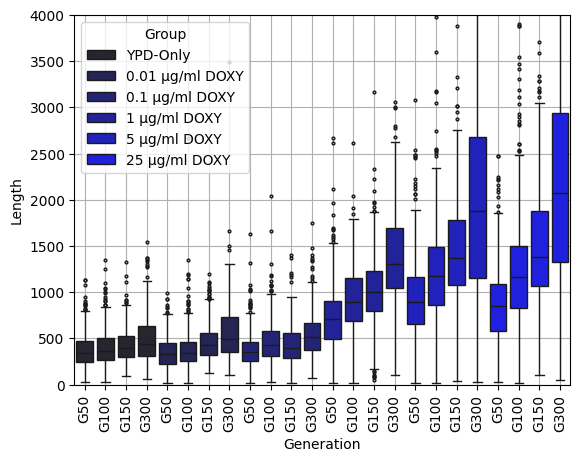

In [14]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="dark:blue", fliersize=2)
new_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xlabel("Generation")
plt.ylim(0, 4000)
plt.xticks(rotation=90)
plt.grid()
plt.savefig("donatelo3_tel_len.png", dpi=450)

In [23]:
(data.loc[data["generation"] == "G300"].groupby("Sample")["Length"].median() - 331)/300

Sample
G300_Doxy-1    0.556667
G300_Doxy-2    0.603333
G300_Doxy-3    3.233333
G300_Doxy-4    5.143333
G300_Doxy-5    5.821667
G300_YPD       0.368333
Name: Length, dtype: float64

## Donatelo 4

In [62]:
base_dir = "../../results/"
files_to_get = [
    "G50_YPD-Only/G50_YPD-Only_Filtred_Results.csv", 
    "G100_YPD-Only/G100_YPD-Only_Filtred_Results.csv", 
    "G150_YPD-Only/G150_YPD-Only_Filtred_Results.csv", 
    "G50_1_DOXY/G50_1_DOXY_Filtred_Results.csv", 
    "G100_1_DOXY/G100_1_DOXY_Filtred_Results.csv", 
    "G150_1_DOXY/G150_1_DOXY_Filtred_Results.csv", 
    "G50_25_DOXY/G50_25_DOXY_Filtred_Results.csv", 
    "G100_25_DOXY/G100_25_DOXY_Filtred_Results.csv", 
    "G150_25_DOXY/G150_25_DOXY_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

            Sample  Length
0     G50_YPD-Only   194.0
1     G50_YPD-Only   152.0
2     G50_YPD-Only    87.0
3     G50_YPD-Only    47.0
4     G50_YPD-Only   150.0
...            ...     ...
2407  G150_25_DOXY   258.0
2408  G150_25_DOXY   727.0
2409  G150_25_DOXY   165.0
2410  G150_25_DOXY   485.0
2411  G150_25_DOXY   608.0

[1833 rows x 2 columns]


In [63]:
group_map = {
    'G50_YPD-Only': 'YPD-Only',
    'G100_YPD-Only': 'YPD-Only',
    'G150_YPD-Only': 'YPD-Only',
    'G50_1_DOXY': '1 µg/ml DOXY',
    'G100_1_DOXY': '1 µg/ml DOXY',
    'G150_1_DOXY': '1 µg/ml DOXY',
    'G50_25_DOXY': '25 µg/ml DOXY',
    'G100_25_DOXY': '25 µg/ml DOXY',
    'G150_25_DOXY': '25 µg/ml DOXY'
}

gen_map = {
    'G50_YPD-Only': 'G50',
    'G100_YPD-Only': 'G100',
    'G150_YPD-Only': 'G150',
    'G50_1_DOXY': 'G50',
    'G100_1_DOXY': 'G100',
    'G150_1_DOXY': 'G150',
    'G50_25_DOXY': 'G50',
    'G100_25_DOXY': 'G100',
    'G150_25_DOXY': 'G150'
}

data['Group'] = data['Sample'].map(group_map)
data["generation"] = data['Sample'].map(gen_map)
data.head()

,Sample,Length,Group,generation
0,G50_YPD-Only,194.0,YPD-Only,G50
1,G50_YPD-Only,152.0,YPD-Only,G50
2,G50_YPD-Only,87.0,YPD-Only,G50
3,G50_YPD-Only,47.0,YPD-Only,G50
4,G50_YPD-Only,150.0,YPD-Only,G50


In [64]:
data.groupby("Sample")["Length"].median()

Sample
G100_1_DOXY      454.0
G100_25_DOXY     636.0
G100_YPD-Only    144.0
G150_1_DOXY      627.0
G150_25_DOXY     596.5
G150_YPD-Only    148.5
G50_1_DOXY       408.0
G50_25_DOXY      479.0
G50_YPD-Only     131.0
Name: Length, dtype: float64

In [70]:
(data.loc[data["generation"] == "G150"].groupby("Sample")["Length"].median() - 118)/150

Sample
G150_1_DOXY      3.393333
G150_25_DOXY     3.190000
G150_YPD-Only    0.203333
Name: Length, dtype: float64

/tmp/ipykernel_363289/2758756037.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


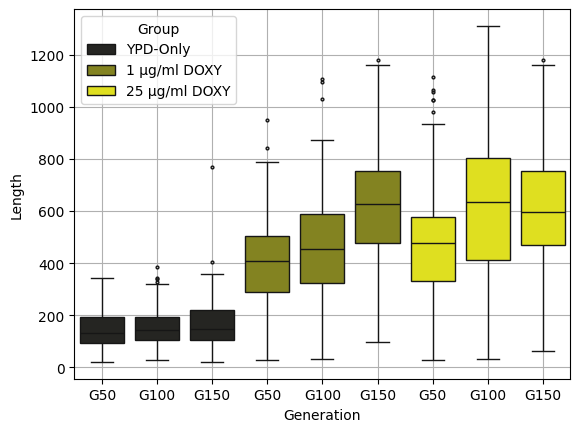

In [65]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="dark:yellow", fliersize=2)
new_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xlabel("Generation")
plt.grid()
plt.savefig("donatelo4_tel_len.png", dpi=450)

/tmp/ipykernel_363289/185158028.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


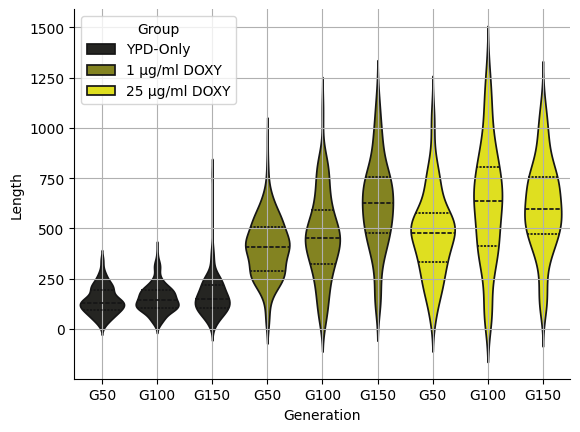

In [66]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="dark:yellow")
new_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xlabel("Generation")
sns.despine()
plt.grid()

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

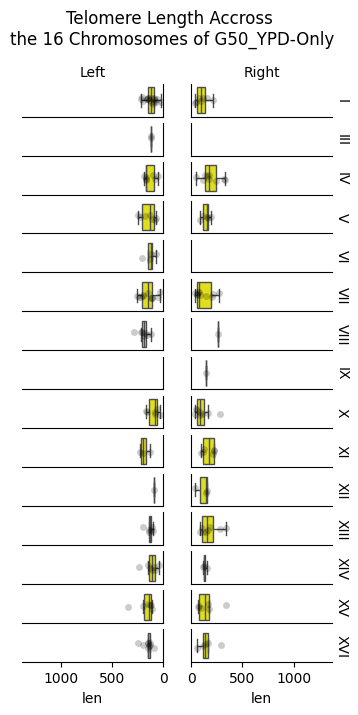

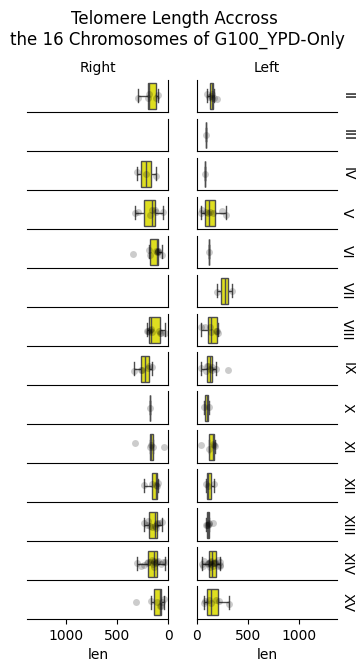

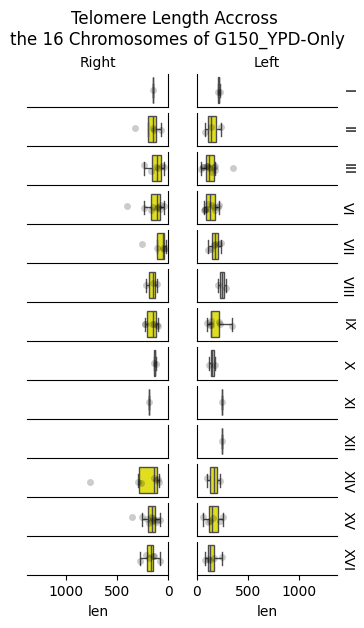

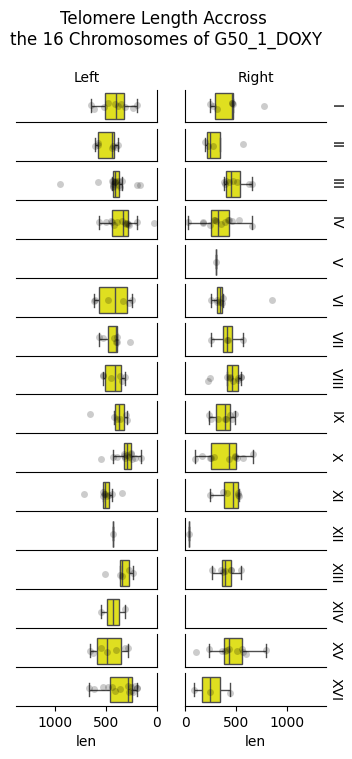

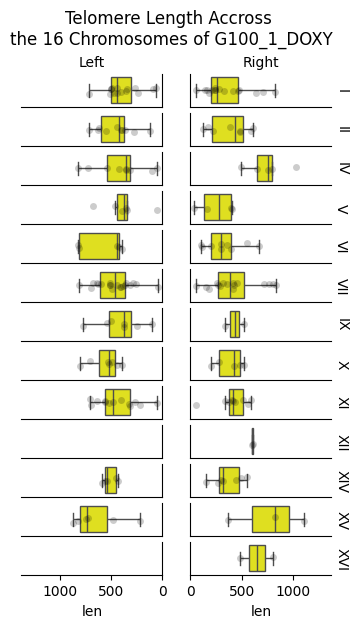

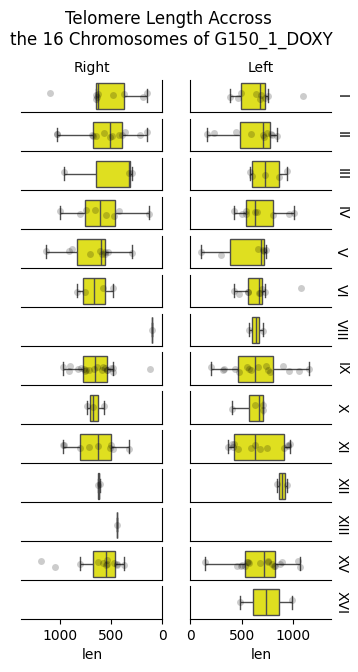

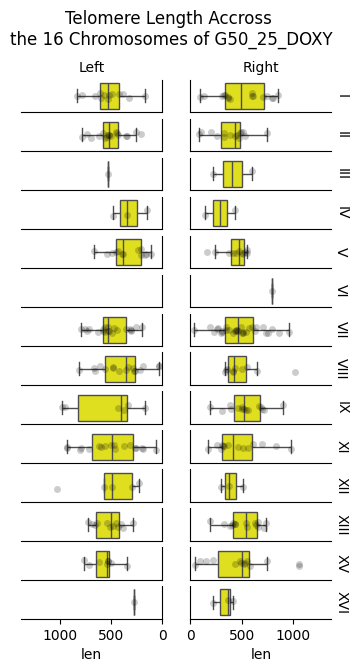

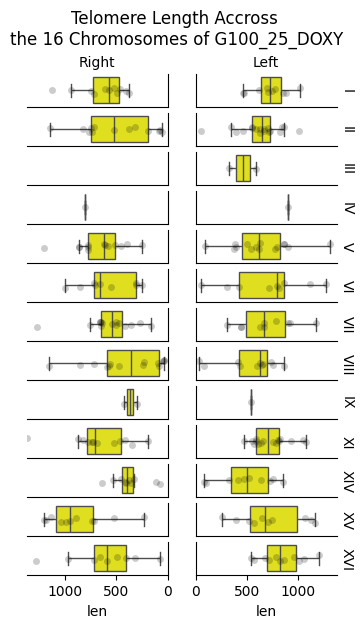

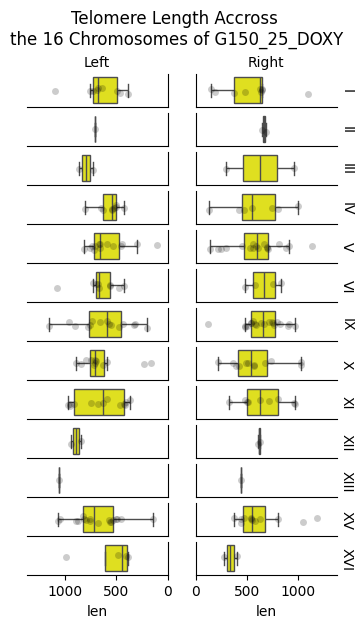

In [9]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross \nthe 16 Chromosomes of " + assemb)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="yellow", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, data["len"].max())
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.savefig(assemb + "_telomere_length_by_chromosome.png", dpi=450)


## Donatelo 5a

In [2]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [17]:
base_dir = "../../results/"
files_to_get = [
    "G600_YPD-Only_Rep1/G600_YPD-Only_Rep1_Filtred_Results.csv", 
    "G600_YPD-Only_Rep2/G600_YPD-Only_Rep2_Filtred_Results.csv", 
    "G600_YPD-Only_Rep3/G600_YPD-Only_Rep3_Filtred_Results.csv",
    "G600_0.01_DOXY_Rep1/G600_0.01_DOXY_Rep1_Filtred_Results.csv", 
    "G600_0.01_DOXY_Rep2/G600_0.01_DOXY_Rep2_Filtred_Results.csv", 
    "G600_0.01_DOXY_Rep3/G600_0.01_DOXY_Rep3_Filtred_Results.csv", 
    "G600_0.1_DOXY_Rep1/G600_0.1_DOXY_Rep1_Filtred_Results.csv", 
    "G600_0.1_DOXY_Rep2/G600_0.1_DOXY_Rep2_Filtred_Results.csv", 
    "G600_0.1_DOXY_Rep3/G600_0.1_DOXY_Rep3_Filtred_Results.csv", 
    "G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv", 
    "G600_25_DOXY_Rep2/G600_25_DOXY_Rep2_Filtred_Results.csv", 
    "G600_25_DOXY_Rep3/G600_25_DOXY_Rep3_Filtred_Results.csv"

]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

                   Sample  Length
0      G600_YPD-Only_Rep1  2103.0
1      G600_YPD-Only_Rep1  2669.0
2      G600_YPD-Only_Rep1  3095.0
3      G600_YPD-Only_Rep1  1809.0
4      G600_YPD-Only_Rep1  1992.0
...                   ...     ...
14715   G600_25_DOXY_Rep3   974.0
14716   G600_25_DOXY_Rep3  1019.0
14717   G600_25_DOXY_Rep3   587.0
14718   G600_25_DOXY_Rep3   146.0
14719   G600_25_DOXY_Rep3   561.0

[10124 rows x 2 columns]


In [18]:
group_map = {
    'G600_0.01_DOXY_Rep1': '0.01 µg/ml DOXY',
    'G600_0.01_DOXY_Rep2': '0.01 µg/ml DOXY',
    'G600_0.01_DOXY_Rep3': '0.01 µg/ml DOXY',
    'G600_0.1_DOXY_Rep1': '0.1 µg/ml DOXY',
    'G600_0.1_DOXY_Rep2': '0.1 µg/ml DOXY',
    'G600_0.1_DOXY_Rep3': '0.1 µg/ml DOXY',
    'G600_25_DOXY_Rep1': '25 µg/ml DOXY',
    'G600_25_DOXY_Rep2': '25 µg/ml DOXY',
    'G600_25_DOXY_Rep3': '25 µg/ml DOXY',
    'G600_YPD-Only_Rep1': 'YPD-Only',
    'G600_YPD-Only_Rep2': 'YPD-Only',
    'G600_YPD-Only_Rep3': 'YPD-Only'
}


data['Group'] = data['Sample'].map(group_map)
data.head()

,Sample,Length,Group
0,G600_YPD-Only_Rep1,2103.0,YPD-Only
1,G600_YPD-Only_Rep1,2669.0,YPD-Only
2,G600_YPD-Only_Rep1,3095.0,YPD-Only
3,G600_YPD-Only_Rep1,1809.0,YPD-Only
4,G600_YPD-Only_Rep1,1992.0,YPD-Only


/tmp/ipykernel_3958180/567143322.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


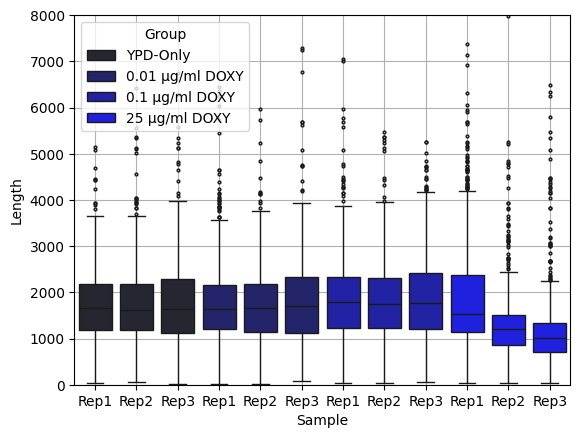

In [19]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="dark:blue", fliersize=2)
new_labels = [label.get_text().split('_')[-1] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.ylim(0, 8000)
plt.grid()
plt.savefig("donatelo5a_tel_len.png", dpi=450)

In [41]:
data.groupby("Sample")["Length"].median()

Sample
G600_0.01_DOXY_Rep1    1633.0
G600_0.01_DOXY_Rep2    1651.5
G600_0.01_DOXY_Rep3    1710.0
G600_0.1_DOXY_Rep1     1780.0
G600_0.1_DOXY_Rep2     1752.0
G600_0.1_DOXY_Rep3     1770.0
G600_25_DOXY_Rep1      1526.5
G600_25_DOXY_Rep2      1214.0
G600_25_DOXY_Rep3      1020.0
G600_YPD-Only_Rep1     1668.0
G600_YPD-Only_Rep2     1618.0
G600_YPD-Only_Rep3     1638.0
Name: Length, dtype: float64

/tmp/ipykernel_3877047/1550906019.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


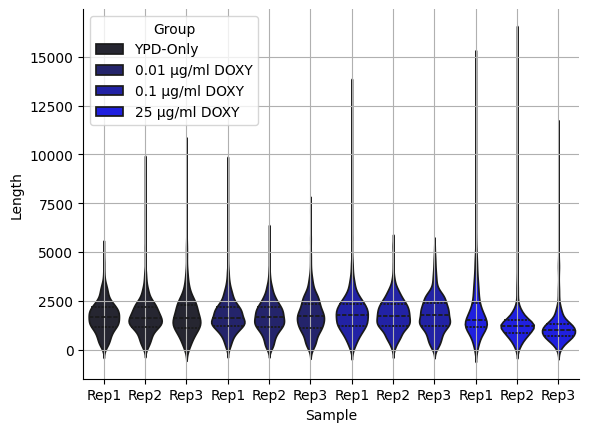

In [93]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="dark:blue")
new_labels = [label.get_text().split('_')[-1] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
sns.despine()
plt.grid()

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

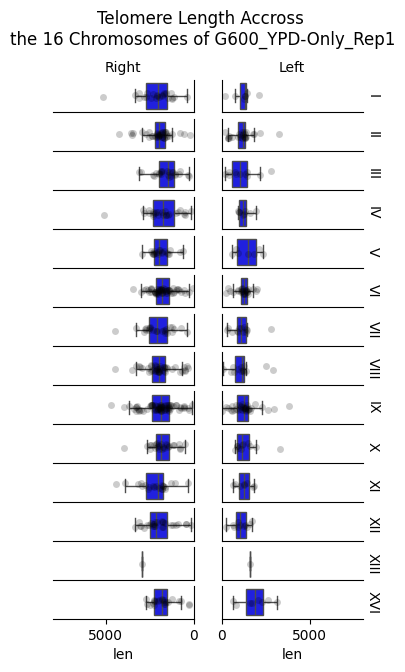

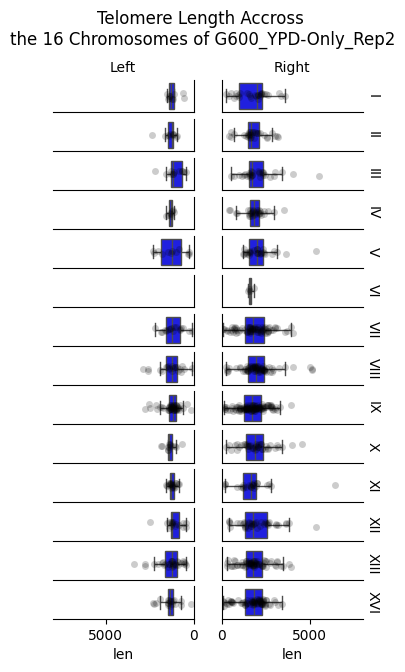

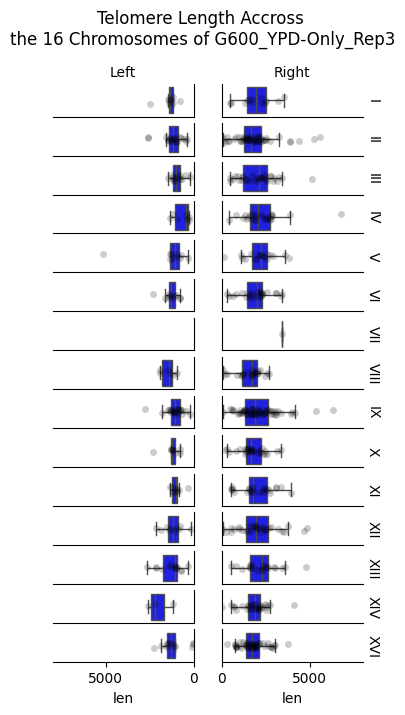

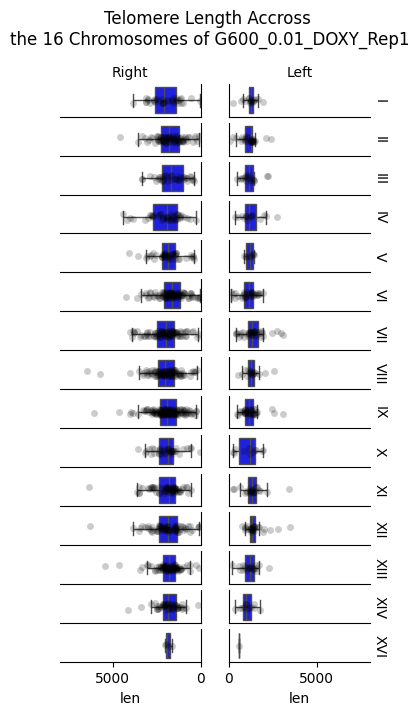

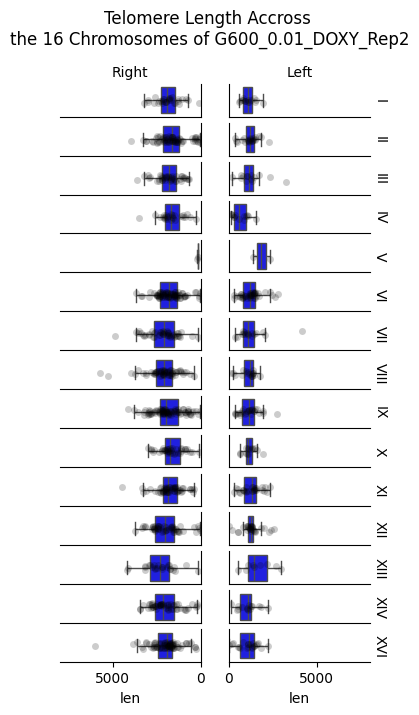

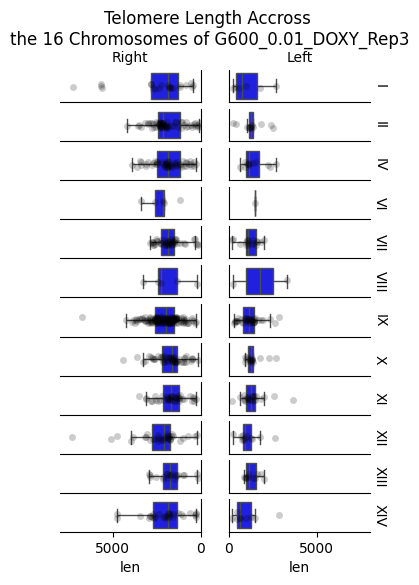

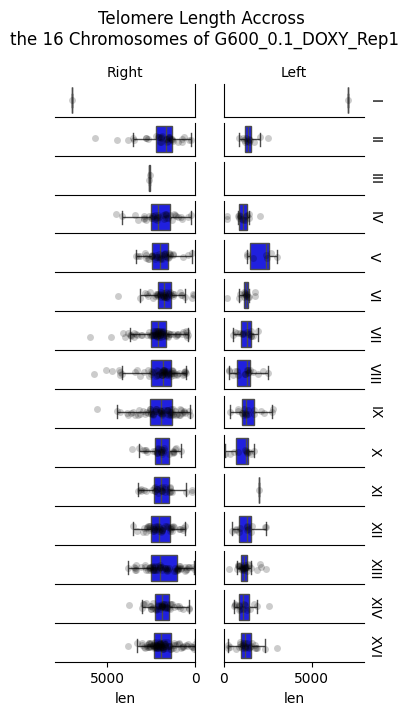

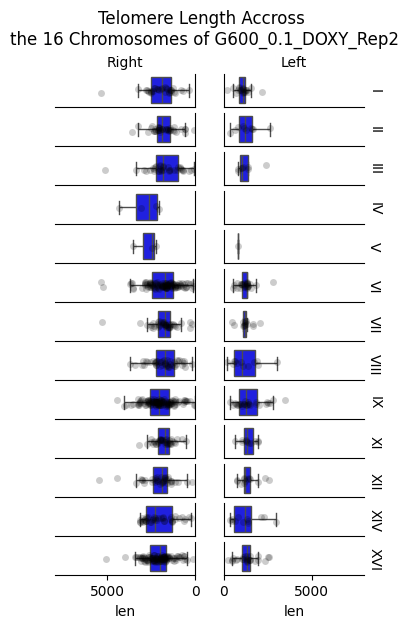

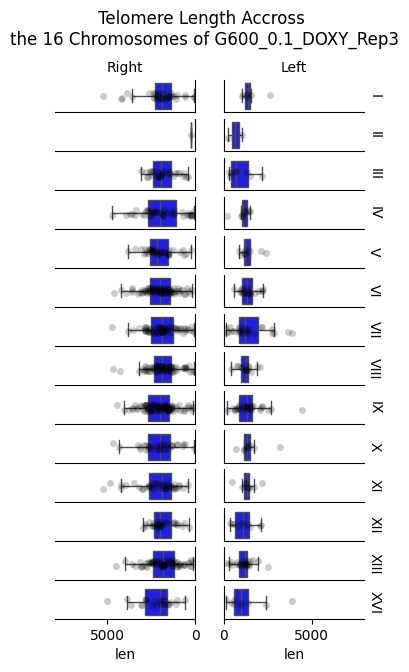

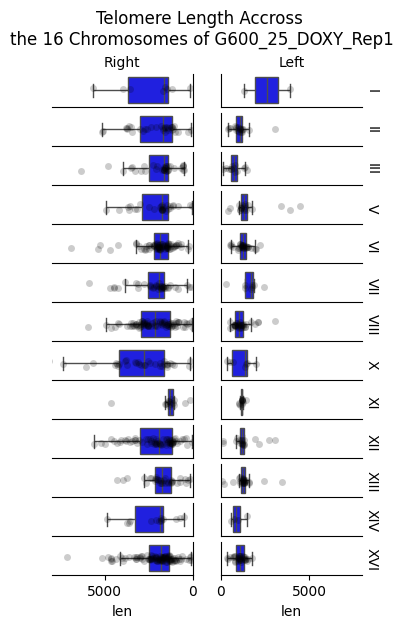

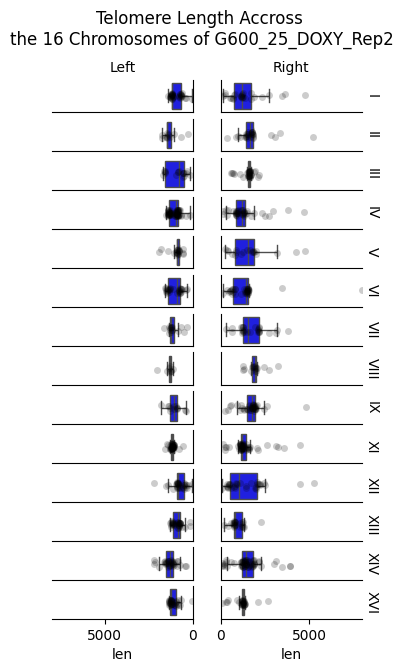

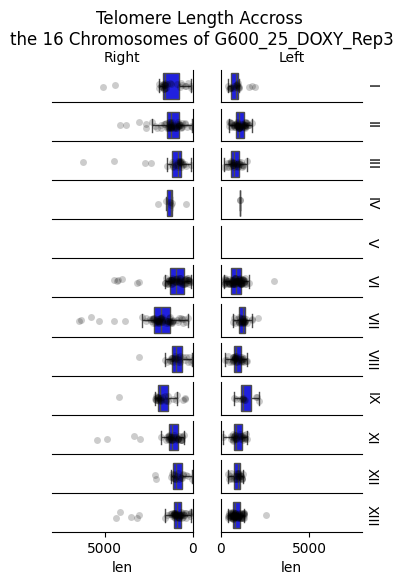

In [5]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross \nthe 16 Chromosomes of " + assemb)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="blue", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, 8000)
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.savefig(assemb + "_telomere_length_by_chromosome.png", dpi=450)


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
base_dir = "../../results/"
files_to_get = [
    "G600_CAS_YPD-Only_Rep1/G600_CAS_YPD-Only_Rep1_Filtred_Results.csv",
    "G600_CAS_YPD-Only_Rep2/G600_CAS_YPD-Only_Rep2_Filtred_Results.csv",
    "G600_CAS_0.01_DOXY_Rep1/G600_CAS_0.01_DOXY_Rep1_Filtred_Results.csv",
    "G600_CAS_0.01_DOXY_Rep2/G600_CAS_0.01_DOXY_Rep2_Filtred_Results.csv",
    "G600_CAS_0.1_DOXY_Rep1/G600_CAS_0.1_DOXY_Rep1_Filtred_Results.csv",
    "G600_CAS_0.1_DOXY_Rep2/G600_CAS_0.1_DOXY_Rep2_Filtred_Results.csv",
    "G600_CAS_25_DOXY_Rep1/G600_CAS_25_DOXY_Rep1_Filtred_Results.csv",
    "G600_CAS_25_DOXY_Rep2/G600_CAS_25_DOXY_Rep2_Filtred_Results.csv"
]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    col_name = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    all_lengths[col_name] = temp_data["len"]

data = pd.DataFrame(all_lengths)
data = data.melt(var_name="Sample", value_name="Length").dropna()

print(data)

                      Sample  Length
0     G600_CAS_YPD-Only_Rep1   867.0
1     G600_CAS_YPD-Only_Rep1   458.0
2     G600_CAS_YPD-Only_Rep1   140.0
3     G600_CAS_YPD-Only_Rep1   865.0
4     G600_CAS_YPD-Only_Rep1   667.0
...                      ...     ...
8211   G600_CAS_25_DOXY_Rep2  3301.0
8212   G600_CAS_25_DOXY_Rep2  1719.0
8213   G600_CAS_25_DOXY_Rep2  3210.0
8214   G600_CAS_25_DOXY_Rep2   619.0
8215   G600_CAS_25_DOXY_Rep2  3498.0

[5795 rows x 2 columns]


In [21]:
group_map = {
    'G600_CAS_YPD-Only_Rep1': 'YPD-Only',
    'G600_CAS_YPD-Only_Rep2': 'YPD-Only',
    'G600_CAS_0.01_DOXY_Rep1': '0.01 µg/ml DOXY',
    'G600_CAS_0.01_DOXY_Rep2': '0.01 µg/ml DOXY',
    'G600_CAS_0.1_DOXY_Rep1': '0.1 µg/ml DOXY',
    'G600_CAS_0.1_DOXY_Rep2': '0.1 µg/ml DOXY',
    'G600_CAS_25_DOXY_Rep1': '25 µg/ml DOXY',
    'G600_CAS_25_DOXY_Rep2': '25 µg/ml DOXY'
}


data['Group'] = data['Sample'].map(group_map)
data.head()

,Sample,Length,Group
0,G600_CAS_YPD-Only_Rep1,867.0,YPD-Only
1,G600_CAS_YPD-Only_Rep1,458.0,YPD-Only
2,G600_CAS_YPD-Only_Rep1,140.0,YPD-Only
3,G600_CAS_YPD-Only_Rep1,865.0,YPD-Only
4,G600_CAS_YPD-Only_Rep1,667.0,YPD-Only


In [15]:
data.groupby("Sample")["Length"].median()

Sample
G600_CAS_0.01_DOXY_Rep1     435.5
G600_CAS_0.01_DOXY_Rep2     363.0
G600_CAS_0.1_DOXY_Rep1      548.5
G600_CAS_0.1_DOXY_Rep2      522.0
G600_CAS_25_DOXY_Rep1      2192.0
G600_CAS_25_DOXY_Rep2      1685.0
G600_CAS_YPD-Only_Rep1      440.0
G600_CAS_YPD-Only_Rep2      310.0
Name: Length, dtype: float64

In [5]:
import seaborn as sns

/tmp/ipykernel_3958180/1310973131.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


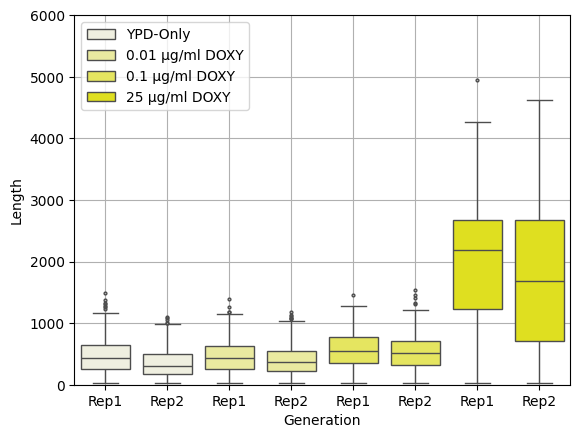

In [22]:
ax = sns.boxplot(data=data, x="Sample", y="Length", hue="Group", palette="light:yellow", fliersize=2)
new_labels = [label.get_text().split('_')[-1] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.ylim(0, 6000)
plt.xlabel("Generation")
plt.legend(loc = "upper left")
plt.grid()
plt.savefig("donatelo5b_tel_len.png", dpi=450)

In [12]:
data.groupby("Sample")["Length"].median()

Sample
G600_CAS_0.01_DOXY_Rep1     435.5
G600_CAS_0.01_DOXY_Rep2     363.0
G600_CAS_0.1_DOXY_Rep1      548.5
G600_CAS_0.1_DOXY_Rep2      522.0
G600_CAS_25_DOXY_Rep1      2192.0
G600_CAS_25_DOXY_Rep2      1685.0
G600_CAS_YPD-Only_Rep1      440.0
G600_CAS_YPD-Only_Rep2      310.0
Name: Length, dtype: float64

/tmp/ipykernel_3936806/289240849.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


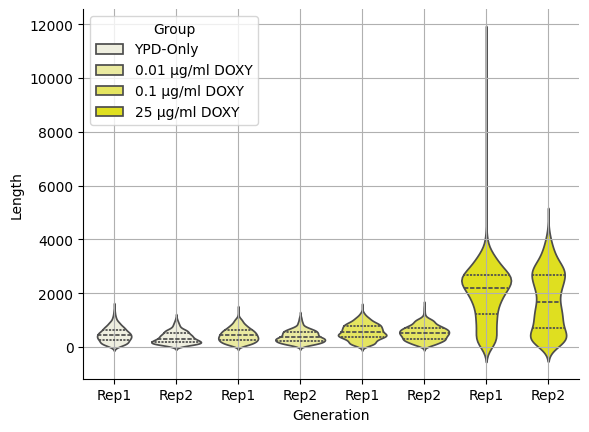

In [8]:
ax = sns.violinplot(data=data, 
                    x="Sample", 
                    y="Length", 
                    hue="Group", 
                    inner="quart",
                    palette="light:yellow")
new_labels = [label.get_text().split('_')[-1] for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xlabel("Generation")
sns.despine()
plt.grid()

/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/lsenez/miniconda3/envs/telofinder/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/lsenez/min

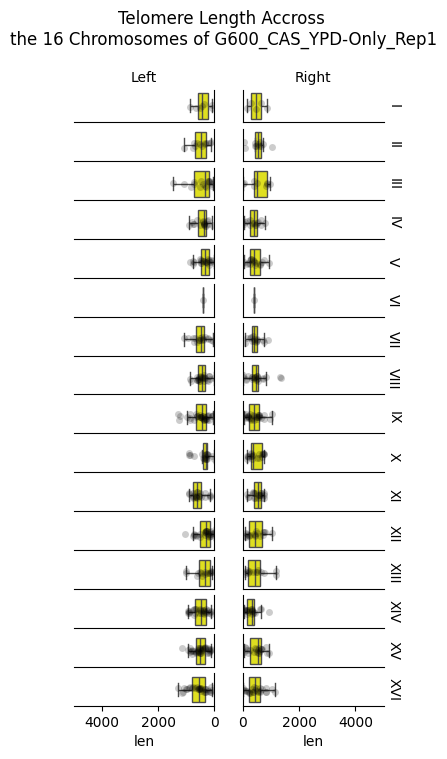

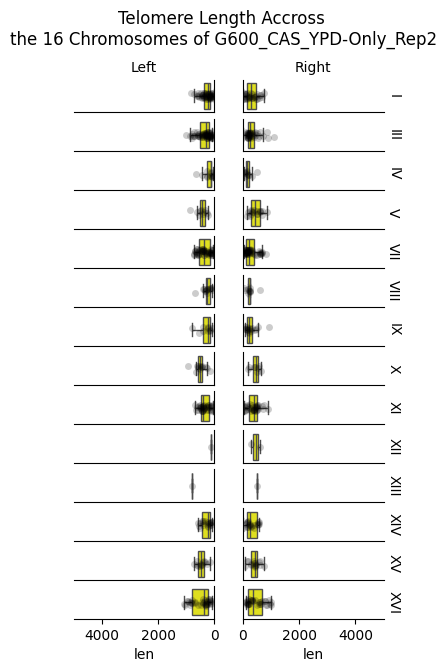

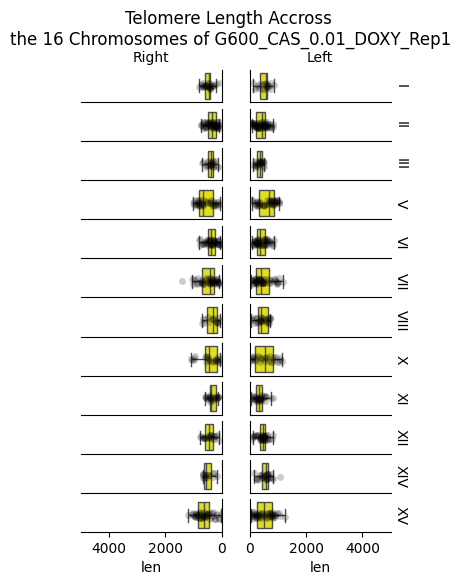

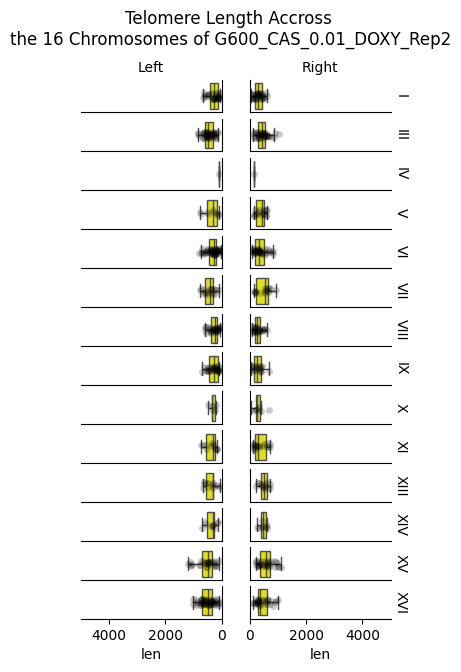

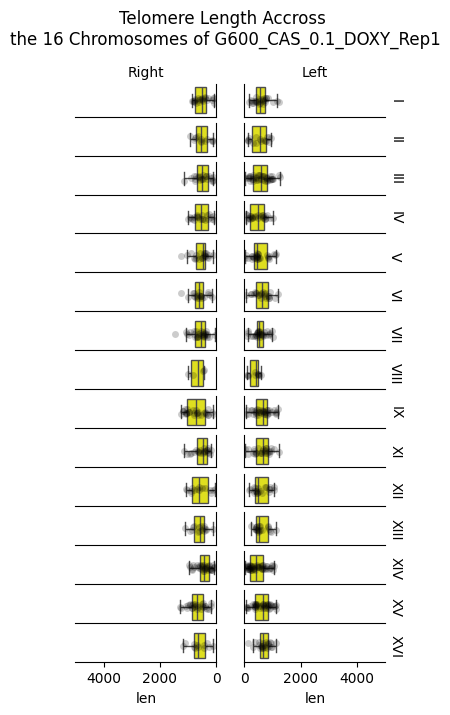

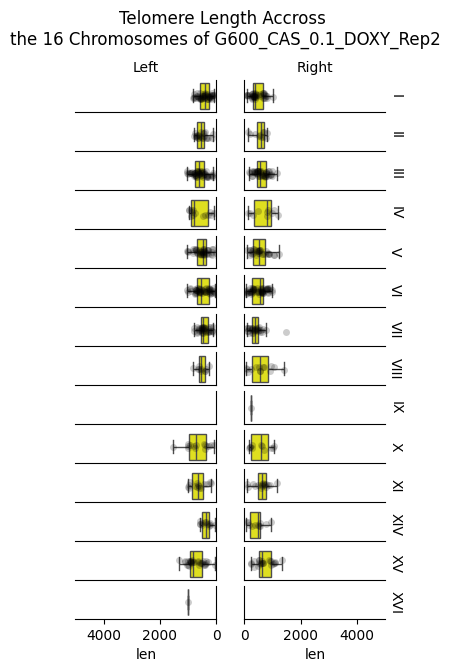

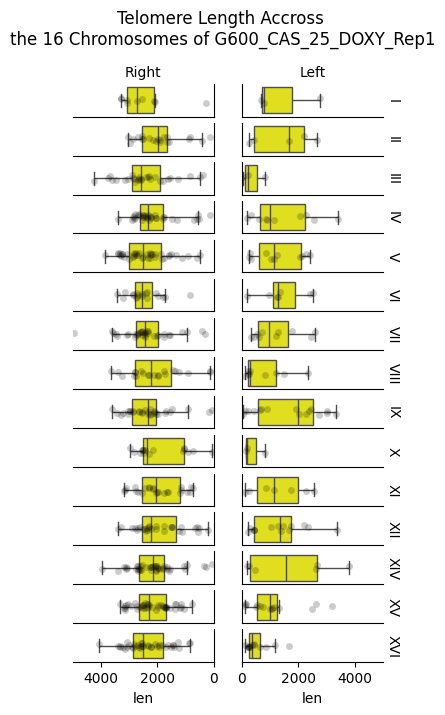

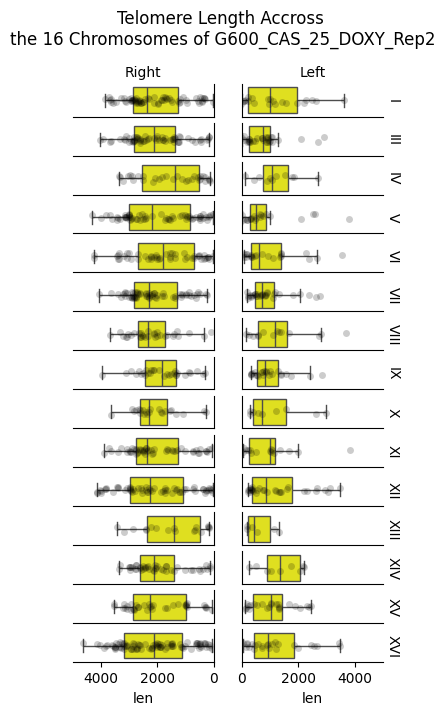

In [6]:
all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)

for assemb in data["assembly"].unique():
    g = sns.FacetGrid(data.loc[data["assembly"] == assemb], row="chrom", col="side", margin_titles=True, height=0.5, aspect=4, sharex=False)

    g.figure.suptitle("Telomere Length Accross \nthe 16 Chromosomes of " + assemb)

    g.map(sns.stripplot, "len", color="black", alpha=0.2, jitter=True)
    g.map(sns.boxplot, "len", color="yellow", fliersize=0)

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.set_xlim(0, 5000)
        if not ax.get_subplotspec().is_last_row():
            ax.tick_params(labelbottom=False, bottom=False)

    for i, ax in enumerate(g.axes[:, 0]):
        ax.invert_xaxis()
        ax.yaxis.set_label_position("right")
        ax.set_yticks([])
        ax.yaxis.tick_right()
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)


    plt.savefig(assemb + "_telomere_length_by_chromosome.png", dpi=450)


# Distribution of telomere length individually

In [32]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
base_dir = "../../results/"
files_to_get = [
    "G600_YPD-Only_Rep1/G600_YPD-Only_Rep1_Filtred_Results.csv", 
    "G600_YPD-Only_Rep2/G600_YPD-Only_Rep2_Filtred_Results.csv", 
    "G600_YPD-Only_Rep3/G600_YPD-Only_Rep3_Filtred_Results.csv",
    # "G600_0.01_DOXY_Rep1/G600_0.01_DOXY_Rep1_Filtred_Results.csv", 
    # "G600_0.01_DOXY_Rep2/G600_0.01_DOXY_Rep2_Filtred_Results.csv", 
    # "G600_0.01_DOXY_Rep3/G600_0.01_DOXY_Rep3_Filtred_Results.csv", 
    # "G600_0.1_DOXY_Rep1/G600_0.1_DOXY_Rep1_Filtred_Results.csv", 
    # "G600_0.1_DOXY_Rep2/G600_0.1_DOXY_Rep2_Filtred_Results.csv", 
    # "G600_0.1_DOXY_Rep3/G600_0.1_DOXY_Rep3_Filtred_Results.csv", 
    "G600_25_DOXY_Rep1/G600_25_DOXY_Rep1_Filtred_Results.csv", 
    "G600_25_DOXY_Rep2/G600_25_DOXY_Rep2_Filtred_Results.csv", 
    "G600_25_DOXY_Rep3/G600_25_DOXY_Rep3_Filtred_Results.csv"

]

full_paths = [os.path.join(base_dir, f) for f in files_to_get]

all_lengths = {}
data = pd.DataFrame(all_lengths)

for path in full_paths:
    temp_data = pd.read_csv(path, sep="\t")
    temp_data["assembly"] = temp_data["assembly"].iloc[0].replace("_genome_ordered", "")
    data = pd.concat([data, temp_data[["assembly", "len", "chrom", "side"]]], ignore_index=True)

data['chrom'] = data['chrom'].str.replace('chr', '', regex=False)
print(data.head())

             assembly     len chrom   side
0  G600_YPD-Only_Rep1  2103.0     I  Right
1  G600_YPD-Only_Rep1  2669.0     I  Right
2  G600_YPD-Only_Rep1  3095.0     I  Right
3  G600_YPD-Only_Rep1  1809.0     I  Right
4  G600_YPD-Only_Rep1  1992.0     I  Right


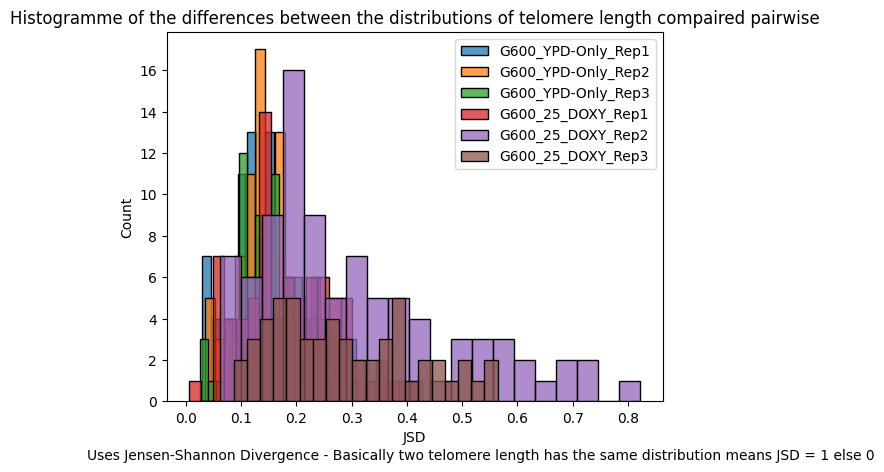

In [51]:
x_range = np.linspace(data["len"].min(), data["len"].max(), 10)


for assemb in data["assembly"].unique():
    working_data = data.loc[data["assembly"] == assemb]
    distance_list = []
    for chrom in range(len(working_data["chrom"].unique())):
        length_distribution = working_data["len"].loc[working_data["chrom"] == working_data["chrom"].unique()[chrom]]
        if len(length_distribution) <= 1: continue
        kde_A = gaussian_kde(length_distribution)(x_range)
        for autre_chrom in range(chrom+1, len(working_data["chrom"].unique())):
            length_distribution_2 = working_data["len"].loc[working_data["chrom"] == working_data["chrom"].unique()[autre_chrom]]
            if len(length_distribution_2) <= 1: continue
            kde_B = gaussian_kde(length_distribution_2)(x_range)
            distance = jensenshannon(kde_A, kde_B)
            distance_list.append(distance)
    
    sns.histplot(distance_list, fill = True, label = assemb, bins=20)

plt.title("Histogramme of the differences between the distributions of telomere length compaired pairwise")
plt.figtext(0, -0.01, "Uses Jensen-Shannon Divergence - Basically two telomere length has the same distribution means JSD = 1 else 0")
plt.xlabel("JSD")
plt.legend()


In [ ]:
# Example: Two of your 32 distributions (binned counts)
# Note: They must be the same length and sum to 1 (probabilities)
dist1 = np.array([0.1, 0.2, 0.7])
dist2 = np.array([0.15, 0.25, 0.6])

distance = jensenshannon(dist1, dist2)
print(f"JSD Distance: {distance:.4f}")

# Number of Y elements

In [52]:
import pandas as pd

In [60]:
data = pd.read_csv("../../results/common/repeat_number.csv", index_col=1)
data = data[["YRF1-1 number", "YRF1-5 number"]]
data["Generation"] = pd.Series([0, 0, 50, 150, 600,600,600,600,600,600,600,600,600,600,600,600], index = data.index)
data

,YRF1-1 number,YRF1-5 number,Generation
Sample,,,
Y2B1115_genome_ordered.fa.out.gff,14,70,0
Y2B1394_genome_ordered.fa.out.gff,12,79,0
A10_genome_ordered.fa.out.gff,10,63,50
G10_genome_ordered.fa.out.gff,17,98,150
G600_YPD-Only_Rep1_genome_ordered.fa.out.gff,15,84,600
G600_YPD-Only_Rep2_genome_ordered.fa.out.gff,14,72,600
G600_YPD-Only_Rep3_genome_ordered.fa.out.gff,12,75,600
G600_0.01_DOXY_Rep1_genome_ordered.fa.out.gff,13,75,600
G600_0.01_DOXY_Rep2_genome_ordered.fa.out.gff,12,70,600


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Y2B1115_genome_ordered.fa.out.gff'),
  Text(1, 0, 'Y2B1394_genome_ordered.fa.out.gff'),
  Text(2, 0, 'A10_genome_ordered.fa.out.gff'),
  Text(3, 0, 'G10_genome_ordered.fa.out.gff'),
  Text(4, 0, 'G600_YPD-Only_Rep1_genome_ordered.fa.out.gff'),
  Text(5, 0, 'G600_YPD-Only_Rep2_genome_ordered.fa.out.gff'),
  Text(6, 0, 'G600_YPD-Only_Rep3_genome_ordered.fa.out.gff'),
  Text(7, 0, 'G600_0.01_DOXY_Rep1_genome_ordered.fa.out.gff'),
  Text(8, 0, 'G600_0.01_DOXY_Rep2_genome_ordered.fa.out.gff'),
  Text(9, 0, 'G600_0.01_DOXY_Rep3_genome_ordered.fa.out.gff'),
  Text(10, 0, 'G600_0.1_DOXY_Rep1_genome_ordered.fa.out.gff'),
  Text(11, 0, 'G600_0.1_DOXY_Rep2_genome_ordered.fa.out.gff'),
  Text(12, 0, 'G600_0.1_DOXY_Rep3_genome_ordered.fa.out.gff'),
  Text(13, 0, 'G600_25_DOXY_Rep1_genome_ordered.fa.out.gff'),
  Text(14, 0, 'G600_25_DOXY_Rep2_genome_ordered.fa.out.gff'),
  Text(15, 0, 'G600_25_DOXY_Rep3_genome_ordered.fa.out.gff'

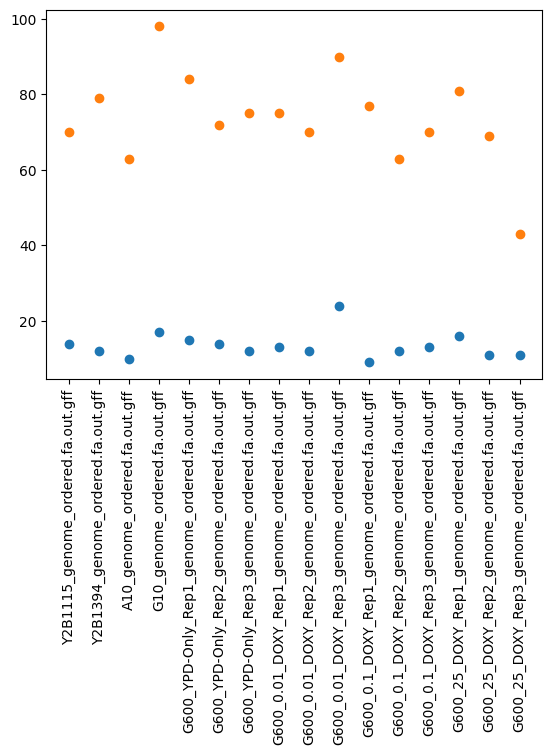

In [65]:
plt.scatter(data.index, data["YRF1-1 number"])
plt.scatter(data.index, data["YRF1-5 number"])
plt.xticks(rotation=90)

# Viviana's csv file

In [2]:
import pandas as pd
import os

In [12]:
data = {}

for file in os.listdir("../../results"):
    if file != "common":
        temp_data = pd.read_csv("../../results/" + file + "/" + file + "_Filtred_Results.csv", sep = "\t")
        data[file] = temp_data["len"]

data = pd.DataFrame(data)
data.to_csv("donatelo_marco_ludo_data.csv")


In [15]:
data_test = pd.read_csv("donatelo_marco_ludo_data.csv", index_col=0)
data_test.head()

,AG50,Y2B1394,BG50,G600_CAS_YPD-Only_Rep1,G50_YPD-Only,G150_1_DOXY,G600_25_DOXY_Rep1,G100_1_DOXY,G600_25_DOXY_Rep3,G600_0.01_DOXY_Rep2,...,Y2B1115,G600_CAS_0.1_DOXY_Rep2,G10,CG0,G600_CAS_25_DOXY_Rep1,G50_1_DOXY,BG0,CG50,G600_YPD-Only_Rep3,G600_0.1_DOXY_Rep1
0,627.0,346.0,1686.0,867.0,194.0,648.0,3568.0,502.0,1920.0,2640.0,...,413.0,425.0,366.0,322.0,286.0,239.0,287.0,788.0,1400.0,7008.0
1,772.0,181.0,1271.0,458.0,150.0,496.0,1692.0,638.0,1586.0,1078.0,...,380.0,95.0,347.0,241.0,3080.0,195.0,189.0,793.0,1462.0,7042.0
2,622.0,307.0,879.0,140.0,152.0,384.0,5681.0,465.0,487.0,103.0,...,467.0,149.0,348.0,377.0,2110.0,521.0,149.0,1128.0,2498.0,239.0
3,575.0,268.0,1315.0,865.0,87.0,482.0,1479.0,506.0,1736.0,623.0,...,454.0,663.0,371.0,106.0,2072.0,377.0,223.0,1070.0,1410.0,1096.0
4,566.0,234.0,917.0,667.0,47.0,687.0,147.0,325.0,1547.0,1267.0,...,434.0,664.0,472.0,232.0,2725.0,242.0,262.0,1046.0,1189.0,1431.0


# SNV of CAS

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [79]:
dico_length_chromo = {
    "chrI":    216883,
    "chrII":   802609,
    "chrIII":  334946,
    "chrIV":   1501069,
    "chrV":    568790,
    "chrVI":   264163,
    "chrVII":  1075400,
    "chrVIII": 566420,
    "chrIX":   449786,
    "chrX":    734841,
    "chrXI":   681839,
    "chrXII":  1059422,
    "chrXIII": 910148,
    "chrXIV":  809632,
    "chrXV":   1024348,
    "chrXVI":  1002199
}


def is_near_telomere(chrom, pos, dico_length, threshold=10000):
    chrom_length = dico_length.get(chrom)
    if chrom_length is None:
        return False
    return pos <= threshold or pos >= (chrom_length - threshold)

In [80]:
cols = ["chrom", "pos", "ref", "alt", "qual", "format", "sample"]

variant_calling_50G = pd.read_csv("../../results/G50_25_DOXY/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_100G = pd.read_csv("../../results/G100_25_DOXY/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_150G = pd.read_csv("../../results/G150_25_DOXY/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep1 = pd.read_csv("../../results/G600_CAS_25_DOXY_Rep1/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep2 = pd.read_csv("../../results/G600_CAS_25_DOXY_Rep2/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)

variant_list = [
    variant_calling_50G,
    variant_calling_100G,
    variant_calling_150G,
    variant_calling_600G_Rep1,
    variant_calling_600G_Rep2
]

for variant_df in variant_list:
    variant_df["presence_percentage"] = variant_df["sample"].str.split(":").str[-1]
    variant_df.drop(["format", "sample"], inplace = True, axis = 1)

In [81]:
print(variant_calling_50G.shape)
print(variant_calling_100G.shape)
print(variant_calling_150G.shape)
print(variant_calling_600G_Rep1.shape)
print(variant_calling_600G_Rep2.shape)

(147, 6)
(175, 6)
(132, 6)
(372, 6)
(797, 6)


In [58]:
variant_calling_600G_Rep1.head()

,chrom,pos,ref,alt,qual,presence_percentage
0,chrI,7178,A,AC,25.70,0.75
1,chrI,7220,C,CT,22.58,0.875
2,chrI,7231,T,TC,21.80,0.8333
3,chrI,104410,AG,A,20.80,0.303
4,chrI,176882,A,T,28.93,0.9731


In [59]:
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']


gff_G50 = pd.read_csv("../../results/G50_25_DOXY/G50_25_DOXY_annotation.gff3",
                    sep='\t', 
                    comment='#', 
                    names=gff_cols)

gff_G50.head()

,seqid,source,type,start,end,score,strand,phase,attributes
0,chrI,Liftoff,gene,7593,7943,.,+,.,ID=CAS_1a.asm01.HP0_G0000010;Name=YER188C-A;co...
1,chrI,Liftoff,mRNA,7593,7943,.,+,.,ID=CAS_1a.asm01.HP0_G0000010.mRNA.1;Name=CAS_1...
2,chrI,Liftoff,exon,7593,7943,.,+,.,ID=CAS_1a.asm01.HP0_G0000010.mRNA.1.exon.1;Nam...
3,chrI,Liftoff,CDS,7593,7943,.,+,.,ID=CAS_1a.asm01.HP0_G0000010.mRNA.1.CDS.1;Name...
4,chrI,Liftoff,gene,8940,9422,.,-,.,ID=CAS_1a.asm01.HP0_G0000020;Name=YAL068C/YBR3...


/tmp/ipykernel_1642515/3918047406.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_variants.drop("telomere", axis = 1, inplace = True)
/tmp/ipykernel_1642515/3918047406.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_variants.rename(columns = {"presence_percentage": key}, inplace=True)


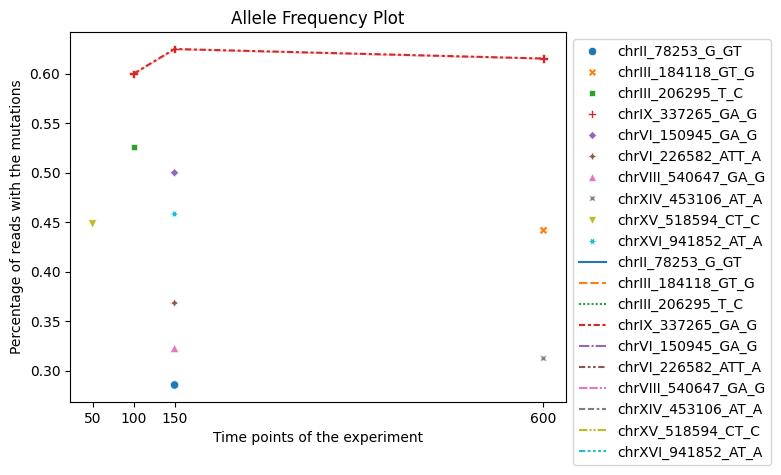

In [62]:
def allele_frequency_plot(variant_dic, gff):

    merged_variants = pd.DataFrame()
    for key in variant_dic.keys():
        variant_df = variant_dic[key]
        variant_df["alt"] = variant_df["alt"].str.split(",")
        variant_df["presence_percentage"] = variant_df["presence_percentage"].str.split(",")
        variant_df = variant_df.explode(["alt", "presence_percentage"])

        variant_df = pd.merge(variant_df, gff, left_on='chrom', right_on='seqid')
        variant_df = variant_df.query('pos >= start and pos <= end')
        variant_df = variant_df[["chrom", "pos", "ref", "alt", "qual", "presence_percentage"]]

        if merged_variants.empty:
            merged_variants = variant_df
            merged_variants.drop("qual", axis = 1, inplace = True)
            merged_variants["presence_percentage"] = merged_variants["presence_percentage"].astype(float)
            merged_variants["telomere"] = merged_variants.apply(lambda row: is_near_telomere(row["chrom"], row["pos"], dico_length_chromo, 20000), axis=1)
            merged_variants = merged_variants[merged_variants["telomere"] == False]
            merged_variants.drop("telomere", axis = 1, inplace = True)
            merged_variants.rename(columns = {"presence_percentage": key}, inplace=True)
        else:
            merged_variants = merged_variants.merge(variant_df,
                                                    on = ["chrom", "pos", "ref", "alt"],
                                                    how = "outer")
            
            merged_variants.drop("qual", axis = 1, inplace = True)
            merged_variants["presence_percentage"] = merged_variants["presence_percentage"].astype(float)
            merged_variants["telomere"] = merged_variants.apply(lambda row: is_near_telomere(row["chrom"], row["pos"], dico_length_chromo, 20000), axis=1)
            merged_variants = merged_variants[merged_variants["telomere"] == False]
            merged_variants.drop("telomere", axis = 1, inplace = True)
            merged_variants.rename(columns = {"presence_percentage": key}, inplace=True)

    merged_variants["pos"] = merged_variants["pos"].astype("str")
    merged_variants["Mutation"] = merged_variants[["chrom", "pos", "ref", "alt"]].agg("_".join, axis=1)
    merged_variants.index = merged_variants["Mutation"]
    merged_variants.drop(["chrom", "pos", "ref", "alt", "Mutation"], axis = 1, inplace = True)

    merged_variants = merged_variants.transpose()
    


    return merged_variants

variant_calling_50G = pd.read_csv("../../results/G50_25_DOXY/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_100G = pd.read_csv("../../results/G100_25_DOXY/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_150G = pd.read_csv("../../results/G150_25_DOXY/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep1 = pd.read_csv("../../results/G600_CAS_25_DOXY_Rep1/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep2 = pd.read_csv("../../results/G600_CAS_25_DOXY_Rep2/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)

variant_dic = {
    "50": variant_calling_50G,
    "100": variant_calling_100G,
    "150": variant_calling_150G,
    "600": variant_calling_600G_Rep1,
}

for key in variant_dic.keys():
    variant_dic[key]["presence_percentage"] = variant_dic[key]["sample"].str.split(":").str[-1]
    variant_dic[key].drop(["format", "sample"], inplace = True, axis = 1)

merged_variants = allele_frequency_plot(variant_dic, gff_G50)
merged_variants.index = merged_variants.index.astype(int)

ax = sns.scatterplot(merged_variants)
sns.lineplot(merged_variants, ax=ax)

plt.xticks(merged_variants.index)
plt.xlabel("Time points of the experiment")
plt.ylabel("Percentage of reads with the mutations")
plt.title("Allele Frequency Plot")
plt.legend(bbox_to_anchor=(1,1))
plt.savefig("Allele Frequency plot CAS Rep1")

In [156]:
merged_variants.loc[merged_variants.index == 100]

Mutation,chrI_176882_A_T,chrI_176925_A_C,chrI_176928_A_AAGTTTCCGCTTTGTGGGAACCCCATAAGG,chrI_176948_A_G,chrI_177020_C_G,chrII_274806_GA_G,chrII_438783_AT_A,chrII_538939_C_CA,chrIII_25335_AT_A,chrIII_206371_C_A,...,chrXIV_81547_C_CT,chrXIV_170306_CA_C,chrXIV_789237_T_G,chrXIV_789276_A_AT,chrXIV_789550_G_A,chrXV_117999_AT_A,chrXV_483680_CA_C,chrXV_518594_CT_C,chrXVI_470643_AT_A,chrXVI_545160_G_GAC
100,0.9388,0.9313,0.8627,0.9427,0.9373,NaN,NaN,NaN,NaN,0.4737,...,NaN,0.4333,NaN,NaN,0.4655,NaN,0.4062,NaN,NaN,NaN


In [48]:
matched_variants = variant_calling_600G_Rep2.merge(variant_calling_50G, on=['chrom', 'pos', "ref", "alt"], how="left", indicator=True)

matched_variants = matched_variants[matched_variants["_merge"] == "left_only"]
matched_variants = matched_variants[["chrom", "pos", "ref", "alt", "qual_x", "presence_percentage_x"]]
matched_variants["telomere"] = matched_variants.apply(lambda row: is_near_telomere(row["chrom"], row["pos"], dico_length_chromo, 20000), axis=1)
matched_variants = matched_variants[matched_variants["telomere"] == False]

matched_variants#.loc[matched_variants["chrom"] == "chrIV"]

,chrom,pos,ref,alt,qual_x,presence_percentage_x,telomere
178,chrII,99966,CT,C,28.09,0.4872,False
179,chrII,188295,G,GA,36.23,0.3163,False
180,chrII,252348,AT,A,22.60,0.4096,False
181,chrII,436420,GA,G,20.07,0.4795,False
182,chrII,570658,GA,G,20.91,0.4512,False
183,chrII,631691,A,AT,26.39,0.2556,False
184,chrII,638597,G,GA,21.75,0.2308,False
185,chrII,754557,G,GA,22.96,0.2818,False
349,chrIV,226609,GA,G,20.82,0.4333,False
350,chrIV,426115,A,AT,23.83,0.4205,False


In [14]:
def mutation_per_genes(variant_call, gff):
    gff = gff.loc[~gff["attributes"].str.contains("Parent")]
    gff["names"] = gff["attributes"].str.extract(r'Name=([^;]+)')

    gff["names"] = gff["names"].str.split("/").str[0]

    merged = pd.merge(variant_call, gff, left_on='chrom', right_on='seqid')
    muts_in_genes = merged.query('pos >= start and pos <= end')
    return muts_in_genes[['chrom', 'pos', 'ref', 'alt', "qual", 'attributes', "names"]]

In [16]:
results = mutation_per_genes(matched_variants, gff_G50)
results[["chrom", "pos", "names", "qual"]].value_counts().head(20)

/tmp/ipykernel_1155453/813753167.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff["names"] = gff["attributes"].str.extract(r'Name=([^;]+)')
/tmp/ipykernel_1155453/813753167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff["names"] = gff["names"].str.split("/").str[0]


chrom   pos     names    qual 
chrII   99966   YBL061C  28.09    1
        638597  YBR215W  21.75    1
chrIV   469378  YDR004W  20.54    1
chrXII  540591  YLR206W  28.83    1
chrXV   382604  YOR043W  20.24    1
Name: count, dtype: int64

# SNV of BY

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [83]:
dico_length_chromo = {
    "chrI":    230482,
    "chrII":   809951,
    "chrIII":  334863,
    "chrIV":   1583289,
    "chrV":    582690,
    "chrVI":   270789,
    "chrVII":  1091749,
    "chrVIII": 579186,
    "chrIX":   441278,
    "chrX":    746366,
    "chrXI":   667378,
    "chrXII":  1089204,
    "chrXIII": 924740,
    "chrXIV":  784451,
    "chrXV":   1092276,
    "chrXVI":  954359
}

def is_near_telomere(chrom, pos, dico_length, threshold=10000):
    chrom_length = dico_length.get(chrom)
    if chrom_length is None:
        return False
    return pos <= threshold or pos >= (chrom_length - threshold)

In [84]:
cols = ["chrom", "pos", "ref", "alt", "qual", "format", "sample"]

variant_calling_G0 = pd.read_csv("../../results/AG0/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G50 = pd.read_csv("../../results/G50_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G100 = pd.read_csv("../../results/G100_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G150 = pd.read_csv("../../results/G150_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G300 = pd.read_csv("../../results/G300_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep1 = pd.read_csv("../../results/G600_25_DOXY_Rep1/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep2 = pd.read_csv("../../results/G600_25_DOXY_Rep2/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep3 = pd.read_csv("../../results/G600_25_DOXY_Rep3/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)

In [85]:
variant_calling_600G_Rep2.head()

,chrom,pos,ref,alt,qual,format,sample
0,chrI,6962,C,A,20.61,GT:GQ:DP:AD:AF,"0/1:20:62:28,29:0.4677"
1,chrI,7001,C,CA,24.54,GT:GQ:DP:AD:AF,"0/1:24:63:30,29:0.4603"
2,chrI,7014,C,CA,22.64,GT:GQ:DP:AD:AF,"0/1:22:63:31,29:0.4603"
3,chrI,7048,A,ACCCACAC,28.82,GT:GQ:DP:AD:AF,"0/1:28:64:27,27:0.4219"
4,chrI,7094,CA,C,30.80,GT:GQ:DP:AD:AF,"1/1:30:67:9,58:0.8657"


In [86]:
print(variant_calling_G0.shape)
print(variant_calling_G50.shape)
print(variant_calling_G100.shape)
print(variant_calling_G150.shape)
print(variant_calling_G300.shape)
print(variant_calling_600G_Rep1.shape)
print(variant_calling_600G_Rep2.shape)
print(variant_calling_600G_Rep3.shape)

(360, 7)
(351, 7)
(287, 7)
(324, 7)
(203, 7)
(381, 7)
(659, 7)
(794, 7)


In [71]:
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']


gff_AG0 = pd.read_csv("../../results/AG0/AG0_annotation.gff3",
                    sep='\t', 
                    comment='#', 
                    names=gff_cols)

gff_AG0.iloc[2779:2785]

,seqid,source,type,start,end,score,strand,phase,attributes
2779,chrIV,Liftoff,mRNA,51422,52480,.,-,.,ID=BY.asm01.HP0_G0006770.mRNA.1;Name=BY.asm01....
2780,chrIV,Liftoff,exon,51422,52480,.,-,.,ID=BY.asm01.HP0_G0006770.mRNA.1.exon.1;Name=BY...
2781,chrIV,Liftoff,CDS,51422,52480,.,-,.,ID=BY.asm01.HP0_G0006770.mRNA.1.CDS.1;Name=BY....
2782,chrIV,Liftoff,gene,52752,54407,.,+,.,ID=BY.asm01.HP0_G0006780;Name=YDL225W;coverage...
2783,chrIV,Liftoff,mRNA,52752,54407,.,+,.,ID=BY.asm01.HP0_G0006780.mRNA.1;Name=BY.asm01....
2784,chrIV,Liftoff,exon,52752,54407,.,+,.,ID=BY.asm01.HP0_G0006780.mRNA.1.exon.1;Name=BY...


In [97]:
def allele_frequency_plot(variant_dic, gff):

    merged_variants = pd.DataFrame()
    for key in variant_dic.keys():
        print(key)
        variant_df = variant_dic[key]
        variant_df["alt"] = variant_df["alt"].str.split(",")
        variant_df["presence_percentage"] = variant_df["presence_percentage"].str.split(",")
        variant_df = variant_df.explode(["alt", "presence_percentage"])

        variant_df = pd.merge(variant_df, gff, left_on='chrom', right_on='seqid')
        variant_df = variant_df.query('pos >= start and pos <= end')
        variant_df = variant_df[["chrom", "pos", "ref", "alt", "qual", "presence_percentage"]]

        if merged_variants.empty:
            merged_variants = variant_df
            merged_variants.drop("qual", axis = 1, inplace = True)
            merged_variants["presence_percentage"] = merged_variants["presence_percentage"].astype(float)
            merged_variants["telomere"] = merged_variants.apply(lambda row: is_near_telomere(row["chrom"], row["pos"], dico_length_chromo, 20000), axis=1)
            merged_variants = merged_variants[merged_variants["telomere"] == False]
            merged_variants.drop("telomere", axis = 1, inplace = True)
            merged_variants.rename(columns = {"presence_percentage": key}, inplace=True)
        else:
            merged_variants = merged_variants.merge(variant_df,
                                                    on = ["chrom", "pos", "ref", "alt"],
                                                    how = "outer")
            
            merged_variants.drop("qual", axis = 1, inplace = True)
            merged_variants["presence_percentage"] = merged_variants["presence_percentage"].astype(float)
            merged_variants["telomere"] = merged_variants.apply(lambda row: is_near_telomere(row["chrom"], row["pos"], dico_length_chromo, 20000), axis=1)
            merged_variants = merged_variants[merged_variants["telomere"] == False]
            merged_variants.drop("telomere", axis = 1, inplace = True)
            merged_variants.rename(columns = {"presence_percentage": key}, inplace=True)

    merged_variants["pos"] = merged_variants["pos"].astype("str")
    merged_variants["Mutation"] = merged_variants[["chrom", "pos", "ref", "alt"]].agg("_".join, axis=1)
    merged_variants.index = merged_variants["Mutation"]
    merged_variants.drop(["chrom", "pos", "ref", "alt", "Mutation"], axis = 1, inplace = True)

    print("Dataframe changed - start transpose")
    merged_variants.drop_duplicates(inplace = True)
    merged_variants = merged_variants.transpose()
    print("Transpose successful")

    return merged_variants

cols = ["chrom", "pos", "ref", "alt", "qual", "format", "sample"]

variant_calling_G0 = pd.read_csv("../../results/AG0/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G50 = pd.read_csv("../../results/G50_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G100 = pd.read_csv("../../results/G100_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G150 = pd.read_csv("../../results/G150_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_G300 = pd.read_csv("../../results/G300_Doxy-5/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep1 = pd.read_csv("../../results/G600_25_DOXY_Rep1/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep2 = pd.read_csv("../../results/G600_25_DOXY_Rep2/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)
variant_calling_600G_Rep3 = pd.read_csv("../../results/G600_25_DOXY_Rep3/summary_variant_counter.csv", sep = "\t", names = cols, index_col = False)

gff_AG0 = pd.read_csv("../../ressources/rep/BY.asm01.HP0.nuclear_genome.tidy.gff3",
                    sep='\t', 
                    comment='#', 
                    names=gff_cols)

variant_dic = {
    "0": variant_calling_G0,
    "50": variant_calling_G50,
    "100": variant_calling_G100,
    "150": variant_calling_G150,
    "300": variant_calling_G300,
    "600": variant_calling_600G_Rep3,
}

for key in variant_dic.keys():
    variant_dic[key]["presence_percentage"] = variant_dic[key]["sample"].str.split(":").str[-1]
    variant_dic[key].drop(["format", "sample"], inplace = True, axis = 1)

merged_variants = allele_frequency_plot(variant_dic, gff_AG0)
merged_variants.index = merged_variants.index.astype(int)
merged_variants

0
50
100


/tmp/ipykernel_1642515/3384014820.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_variants.drop("telomere", axis = 1, inplace = True)
/tmp/ipykernel_1642515/3384014820.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_variants.rename(columns = {"presence_percentage": key}, inplace=True)


150
300
600
Dataframe changed - start transpose
Transpose successful


Mutation,chrI_41974_T_G,chrI_43337_G_GA,chrI_48964_T_G,chrI_109240_GT_G,chrI_116230_GT_G,chrI_196766_TA_T,chrI_209243_C_CA,chrII_112070_CGAG_C,chrII_193810_GA_G,chrII_212634_T_TA,...,chrXVI_852862_A_G,chrXVI_852877_G_A,chrXVI_853247_C_T,chrXVI_853299_G_A,chrXVI_853309_C_T,chrXVI_853310_G_A,chrXVI_854257_G_T,chrXVI_854542_T_C,chrXVI_854575_T_A,chrXVI_855011_C_T
0,0.4865,NaN,NaN,0.3889,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,0.6316,NaN,0.5625,NaN,NaN,0.3333,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,NaN,NaN,0.5909,NaN,NaN,0.6607,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,NaN,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
300,NaN,NaN,NaN,NaN,0.5294,0.6883,NaN,NaN,0.4444,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
600,0.5167,0.2459,NaN,NaN,NaN,NaN,0.4857,NaN,NaN,0.3043,...,0.3265,0.3469,0.3529,0.3654,0.3462,0.3725,0.38,0.36,0.3922,0.3585


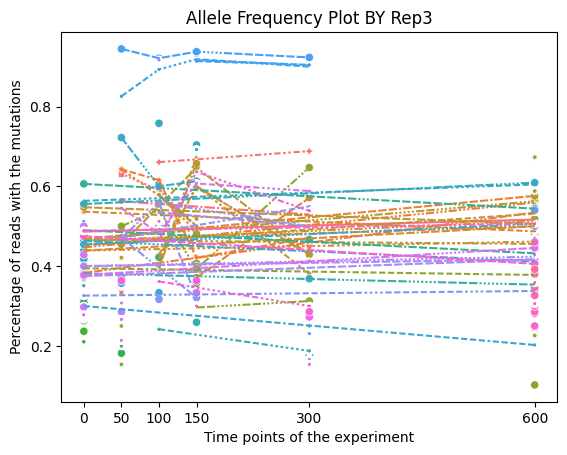

In [98]:
ax = sns.scatterplot(merged_variants)
sns.lineplot(merged_variants, ax=ax, legend=False)

plt.xticks(merged_variants.index)
plt.xlabel("Time points of the experiment")
plt.ylabel("Percentage of reads with the mutations")
plt.title("Allele Frequency Plot BY Rep3")
plt.legend([], [], frameon = False)
plt.savefig("Allele Frequency Plot BY Rep3 no legend", dpi = 600, bbox_inches='tight')

In [32]:
matched_variants = variant_calling_600G_Rep2.merge(variant_calling_G0, on=['chrom', 'pos', "ref", "alt"], how="left", indicator=True)

matched_variants = matched_variants[matched_variants["_merge"] == "left_only"]
matched_variants = matched_variants[["chrom", "pos", "ref", "alt"]]
matched_variants["telomere"] = matched_variants.apply(lambda row: is_near_telomere(row["chrom"], row["pos"], dico_length_chromo, 20000), axis=1)
matched_variants = matched_variants[matched_variants["telomere"] == False]

matched_variants.loc[matched_variants["chrom"] == "chrXII"]

,chrom,pos,ref,alt,telomere
526,chrXII,163153,T,A,False
527,chrXII,440031,T,TTA,False
528,chrXII,440064,G,A,False
529,chrXII,440074,T,TA,False
530,chrXII,440076,T,A,False
531,chrXII,440079,T,A,False
532,chrXII,440156,TGTTTGCCGC,T,False
533,chrXII,507853,AT,A,False
534,chrXII,702052,A,AT,False
535,chrXII,732277,T,G,False


In [153]:
def mutation_per_genes(variant_call, gff):
    gff = gff.loc[~gff["attributes"].str.contains("Parent")]
    gff["names"] = gff["attributes"].str.extract(r'Name=([^;]+)')

    gff["names"] = gff["names"].str.split("/").str[0]

    merged = pd.merge(variant_call, gff, left_on='chrom', right_on='seqid')
    muts_in_genes = merged.query('pos >= start and pos <= end')
    return muts_in_genes[['chrom', 'pos', 'ref', 'alt', 'attributes', "names"]]

In [154]:
results = mutation_per_genes(matched_variants, gff_AG0)
results[["chrom", "pos", "names"]].value_counts().head(20)

/tmp/ipykernel_132516/1762312643.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff["names"] = gff["attributes"].str.extract(r'Name=([^;]+)')
/tmp/ipykernel_132516/1762312643.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff["names"] = gff["names"].str.split("/").str[0]


chrom    pos      names                
chrIV    47913    ho::pMYO2_rtTA_tPGK1     1
         420571   YDL019C                  1
         542534   YDR038C                  1
         622359   YDR083W                  1
         1553584  BY.asm01.HP0_G0013840    1
         1560488  BY.asm01.HP0_G0013850    1
         1560570  BY.asm01.HP0_G0013850    1
         1560661  BY.asm01.HP0_G0013850    1
         1560750  BY.asm01.HP0_G0013850    1
         1561215  BY.asm01.HP0_G0013850    1
         1561226  BY.asm01.HP0_G0013850    1
         1561243  BY.asm01.HP0_G0013850    1
         1561472  BY.asm01.HP0_G0013850    1
chrIX    348626   YIL005W                  1
chrV     24360    YEL069C                  1
chrVI    76993    YFL031W                  1
chrVII   921244   YGR214W                  1
chrVIII  522507   YHR201C                  1
         551739   BY.asm01.HP0_G0025680    1
chrXII   584167   YLR224W                  1
Name: count, dtype: int64

# Get all reads with only telomere sequences

In [49]:
import re
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import concurrent.futures

In [50]:
def nombre_reads_telomere_only(filepath):
    with gzip.open(filepath, "rt") as file:
        lignes = file.readlines()

        total_compteur = 0
        less_than_100_compteur = 0

        for i in range(0, len(lignes), 2):
            if re.fullmatch(r"[TG]+", lignes[i+1].strip()) or re.fullmatch(r"[CA]+", lignes[i+1].strip()):
                if len(lignes[i+1]) <= 100: #100 should be enough to map correctly to the consensus part 
                    less_than_100_compteur += 1
                total_compteur += 1

    return total_compteur, less_than_100_compteur

In [51]:
def nombre_reads_telomere_only_analysis(filepath):
    with gzip.open(filepath, "rt") as file:
        lignes = file.readlines()

        compteur = 0
        lengths = []

        for i in range(0, len(lignes), 2):
            if re.fullmatch(r"[TG]+", lignes[i+1].strip()) or re.fullmatch(r"[CA]+", lignes[i+1].strip()):
                compteur += 1
                lengths.append(len(lignes[i+1].strip()))

    return compteur, lengths

## BY

Nombre de reads ne contenant que des séquences télomériques (rep1) : 212
Nombre de reads ne contenant que des séquences télomériques (rep2) : 226
Nombre de reads ne contenant que des séquences télomériques (rep3) : 190


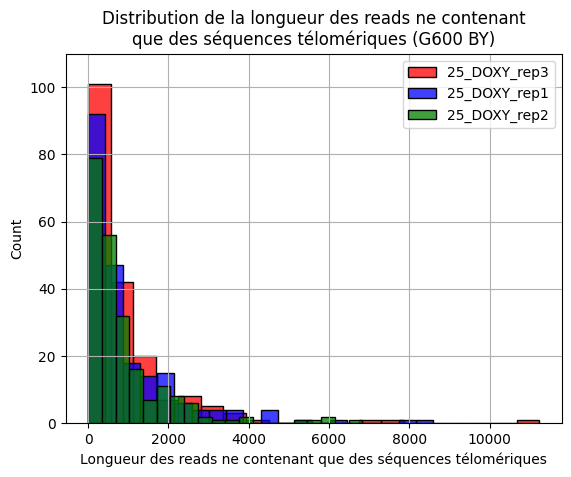

In [ ]:
compteur_rep1, lengths_rep1 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_25_DOXY_Rep1/G600_25_DOXY_Rep1.fastq.gz")
compteur_rep2, lengths_rep2 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_25_DOXY_Rep2/G600_25_DOXY_Rep2.fastq.gz")
compteur_rep3, lengths_rep3 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_25_DOXY_Rep3/G600_25_DOXY_Rep3.fastq.gz")

print(f"Nombre de reads ne contenant que des séquences télomériques (rep1) : {compteur_rep1}")
print(f"Nombre de reads ne contenant que des séquences télomériques (rep2) : {compteur_rep2}")
print(f"Nombre de reads ne contenant que des séquences télomériques (rep3) : {compteur_rep3}")

sns.histplot(lengths_rep3, fill = True, label = "25_DOXY_rep3", color='red', edgecolor='black', bins=20)
sns.histplot(lengths_rep1, fill = True, label = "25_DOXY_rep1", color='blue', edgecolor='black', bins=20)
sns.histplot(lengths_rep2, fill = True, label = "25_DOXY_rep2", color='green', edgecolor='black', bins=20)

#plt.xticks(bins, rotation=90)
plt.ylim(0, 110)
plt.xlabel("Longueur des reads ne contenant que des séquences télomériques")
plt.title("Distribution de la longueur des reads ne contenant\nque des séquences télomériques (G600 BY)")
plt.grid()
plt.legend()
plt.savefig("donatelo_telomere_only_BY_read_length_distribution_25_DOXY.png", dpi=450)

Nombre de reads ne contenant que des séquences télomériques (rep1) : 62
Nombre de reads ne contenant que des séquences télomériques (rep2) : 106
Nombre de reads ne contenant que des séquences télomériques (rep3) : 76


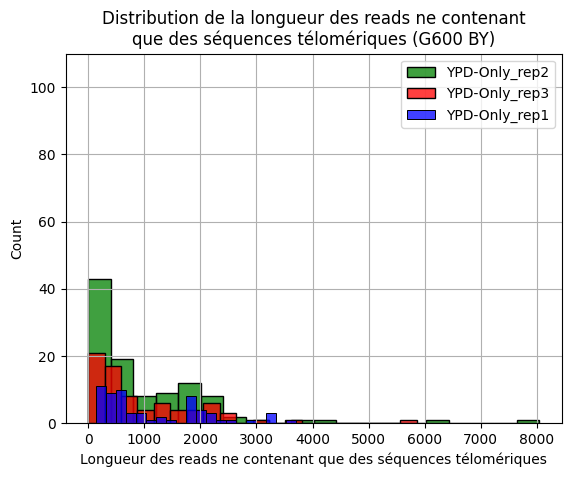

In [7]:
compteur_rep1, lengths_rep1 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_YPD-Only_Rep1/G600_YPD-Only_Rep1.fastq.gz")
compteur_rep2, lengths_rep2 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_YPD-Only_Rep2/G600_YPD-Only_Rep2.fastq.gz")
compteur_rep3, lengths_rep3 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_YPD-Only_Rep3/G600_YPD-Only_Rep3.fastq.gz")

print(f"Nombre de reads ne contenant que des séquences télomériques (rep1) : {compteur_rep1}")
print(f"Nombre de reads ne contenant que des séquences télomériques (rep2) : {compteur_rep2}")
print(f"Nombre de reads ne contenant que des séquences télomériques (rep3) : {compteur_rep3}")

sns.histplot(lengths_rep2, fill = True, label = "YPD-Only_rep2", color='green', edgecolor='black', bins=20)
sns.histplot(lengths_rep3, fill = True, label = "YPD-Only_rep3", color='red', edgecolor='black', bins=20)
sns.histplot(lengths_rep1, fill = True, label = "YPD-Only_rep1", color='blue', edgecolor='black', bins=20)

#plt.xticks(bins, rotation=90)
plt.ylim(0, 110)
plt.xlabel("Longueur des reads ne contenant que des séquences télomériques")
plt.title("Distribution de la longueur des reads ne contenant\nque des séquences télomériques (G600 BY)")
plt.grid()
plt.legend()
plt.savefig("donatelo_telomere_only_BY_read_length_distribution_YPD.png", dpi=450)

## CAS

Nombre de reads ne contenant que des séquences télomériques (rep1) : 58
Nombre de reads ne contenant que des séquences télomériques (rep2) : 444


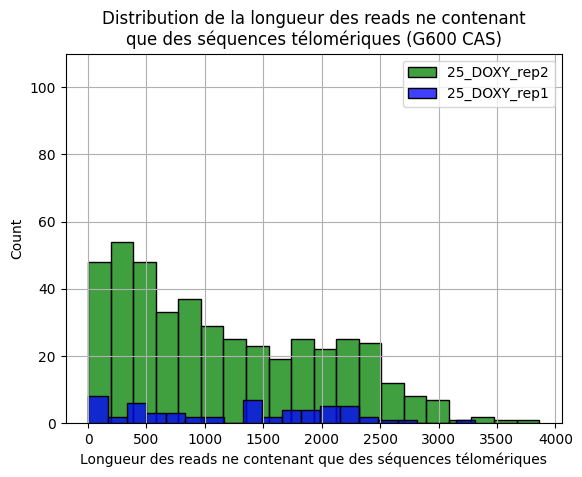

In [52]:
compteur_rep1, lengths_rep1 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_CAS_25_DOXY_Rep1/G600_CAS_25_DOXY_Rep1.fastq.gz")
compteur_rep2, lengths_rep2 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_CAS_25_DOXY_Rep2/G600_CAS_25_DOXY_Rep2.fastq.gz")

print(f"Nombre de reads ne contenant que des séquences télomériques (rep1) : {compteur_rep1}")
print(f"Nombre de reads ne contenant que des séquences télomériques (rep2) : {compteur_rep2}")

sns.histplot(lengths_rep2, fill = True, label = "25_DOXY_rep2", color='green', edgecolor='black', bins=20)
sns.histplot(lengths_rep1, fill = True, label = "25_DOXY_rep1", color='blue', edgecolor='black', bins=20)

#plt.xticks(bins, rotation=90)
plt.ylim(0, 110)
plt.xlabel("Longueur des reads ne contenant que des séquences télomériques")
plt.title("Distribution de la longueur des reads ne contenant\nque des séquences télomériques (G600 CAS)")
plt.grid()
plt.legend()
plt.savefig("donatelo_telomere_only_CAS_read_length_distribution_25_DOXY.png", dpi=450)

Nombre de reads ne contenant que des séquences télomériques (rep1) : 6
Nombre de reads ne contenant que des séquences télomériques (rep2) : 21


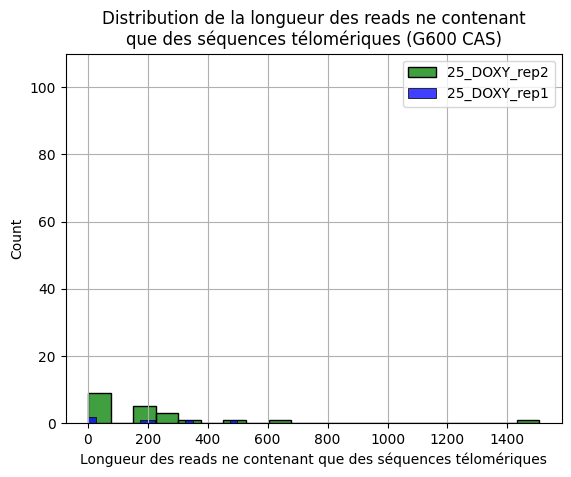

In [31]:
compteur_rep1, lengths_rep1 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_CAS_YPD-Only_Rep1/G600_CAS_YPD-Only_Rep1.fastq.gz")
compteur_rep2, lengths_rep2 = nombre_reads_telomere_only_analysis("../../ressources/data/G600_CAS_YPD-Only_Rep2/G600_CAS_YPD-Only_Rep2.fastq.gz")

print(f"Nombre de reads ne contenant que des séquences télomériques (rep1) : {compteur_rep1}")
print(f"Nombre de reads ne contenant que des séquences télomériques (rep2) : {compteur_rep2}")

sns.histplot(lengths_rep2, fill = True, label = "25_DOXY_rep2", color='green', edgecolor='black', bins=20)
sns.histplot(lengths_rep1, fill = True, label = "25_DOXY_rep1", color='blue', edgecolor='black', bins=20)

#plt.xticks(bins, rotation=90)
plt.ylim(0, 110)
plt.xlabel("Longueur des reads ne contenant que des séquences télomériques")
plt.title("Distribution de la longueur des reads ne contenant\nque des séquences télomériques (G600 CAS)")
plt.grid()
plt.legend()
plt.savefig("donatelo_telomere_only_CAS_read_length_distribution_YPD.png", dpi=450)

## Heatmap

In [55]:
nbr_telomere_seqs = {}

doxycycline = [25, 25, 25, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0, 0, 0]

samples_BY = [
    "G600_25_DOXY_Rep1", "G600_25_DOXY_Rep2", "G600_25_DOXY_Rep3",
    "G600_0.1_DOXY_Rep1", "G600_0.1_DOXY_Rep2", "G600_0.1_DOXY_Rep3",
    "G600_0.01_DOXY_Rep1", "G600_0.01_DOXY_Rep2", "G600_0.01_DOXY_Rep3",
    "G600_YPD-Only_Rep1", "G600_YPD-Only_Rep2", "G600_YPD-Only_Rep3",
    "G50_YPD", "G100_YPD", "G150_YPD", "G300_YPD",
    "G50_Doxy-1", "G100_Doxy-1", "G150_Doxy-1", "G300_Doxy-1",
    "G50_Doxy-2", "G100_Doxy-2", "G150_Doxy-2", "G300_Doxy-2",
    "G50_Doxy-3", "G100_Doxy-3", "G150_Doxy-3", "G300_Doxy-3",
    "G50_Doxy-4", "G100_Doxy-4", "G150_Doxy-4", "G300_Doxy-4",
    "G50_Doxy-5", "G100_Doxy-5", "G150_Doxy-5", "G300_Doxy-5",
]

samples_CAS = [
    "G600_CAS_25_DOXY_Rep1", "G600_CAS_25_DOXY_Rep2",
    "G600_CAS_0.1_DOXY_Rep1", "G600_CAS_0.1_DOXY_Rep2",
    "G600_CAS_0.01_DOXY_Rep1", "G600_CAS_0.01_DOXY_Rep2",
    "G600_CAS_YPD-Only_Rep1", "G600_CAS_YPD-Only_Rep2",
    "G50_YPD-Only", "G100_YPD-Only", "G150_YPD-Only",
    "G50_1_DOXY", "G100_1_DOXY", "G150_1_DOXY",
    "G50_25_DOXY", "G100_25_DOXY", "G150_25_DOXY",
]

def process_sample(sample):
    path = f"../../ressources/data/{sample}/{sample}.fastq.gz"
    compteur, compteur_less_than_100 = nombre_reads_telomere_only(path)
    return sample.replace("_CAS", ""), [compteur, compteur_less_than_100]

with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(process_sample, samples_CAS))

nbr_telomere_seqs = dict(results)

nbr_telomere_seqs_df = pd.DataFrame(nbr_telomere_seqs, index=["Total reads ne contenant que des séquences télomériques", "Reads ne contenant que des séquences télomériques de longueur <= 100"])
nbr_telomere_seqs_df = nbr_telomere_seqs_df.transpose()

In [56]:
custom_order = ["0", "0.01", "0.1", "1", "5", "25"]
nbr_telomere_seqs_df["Doxycycline"] = nbr_telomere_seqs_df.index.str.split("_").str[1]

doxy_map = {
    "YPD": "0",
    "Doxy-1": "0.01",
    "Doxy-2": "0.1",
    "Doxy-3": "1",
    "Doxy-4": "5",
    "Doxy-5": "25",
    "25": "25",
    "0.1": "0.1",
    "0.01": "0.01",
    "YPD-Only": "0",
    "1": "1",
}

nbr_telomere_seqs_df["Doxycycline"] = nbr_telomere_seqs_df["Doxycycline"].map(doxy_map)

nbr_telomere_seqs_df["Doxycycline"] = pd.Categorical(nbr_telomere_seqs_df["Doxycycline"], categories=custom_order, ordered=True)
nbr_telomere_seqs_df["Generation"] = nbr_telomere_seqs_df.index.str.split("_").str[0]
nbr_telomere_seqs_df["Generation"] = nbr_telomere_seqs_df["Generation"].str.replace("G", "").astype(int)
#nbr_telomere_seqs_df.drop(index="G600_25_DOXY_Rep2", inplace = True)
nbr_telomere_seqs_df

,Total reads ne contenant que des séquences télomériques,Reads ne contenant que des séquences télomériques de longueur <= 100,Doxycycline,Generation
G600_25_DOXY_Rep1,58,6,25,600
G600_25_DOXY_Rep2,444,22,25,600
G600_0.1_DOXY_Rep1,8,4,0.1,600
G600_0.1_DOXY_Rep2,27,10,0.1,600
G600_0.01_DOXY_Rep1,19,5,0.01,600
G600_0.01_DOXY_Rep2,15,5,0.01,600
G600_YPD-Only_Rep1,6,2,0,600
G600_YPD-Only_Rep2,21,9,0,600
G50_YPD-Only,8,4,0,50
G100_YPD-Only,7,5,0,100


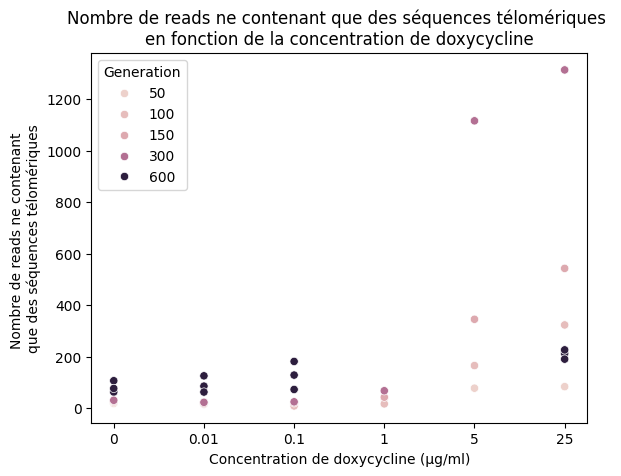

In [41]:
sns.scatterplot(data=nbr_telomere_seqs_df, 
                x="Doxycycline", 
                y="Total reads ne contenant que des séquences télomériques",
                hue="Generation")

plt.title("Nombre de reads ne contenant que des séquences télomériques \nen fonction de la concentration de doxycycline")
plt.xlabel("Concentration de doxycycline (µg/ml)")
plt.ylabel("Nombre de reads ne contenant \nque des séquences télomériques")
plt.savefig("donatelo_BY_number_of_telomere_only_reads_by_doxycycline_concentration.png", dpi=450)

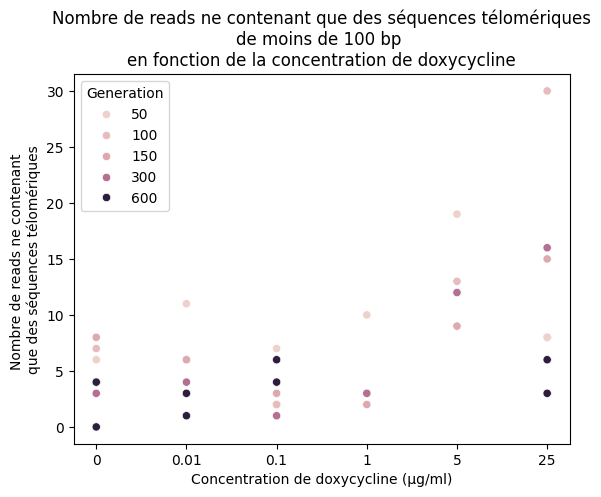

In [42]:
sns.scatterplot(data=nbr_telomere_seqs_df, 
                x="Doxycycline", 
                y="Reads ne contenant que des séquences télomériques de longueur <= 100",
                hue="Generation")

plt.title("Nombre de reads ne contenant que des séquences télomériques\nde moins de 100 bp \nen fonction de la concentration de doxycycline")
plt.xlabel("Concentration de doxycycline (µg/ml)")
plt.ylabel("Nombre de reads ne contenant \nque des séquences télomériques")
plt.savefig("donatelo_BY_number_of_telomere_only_reads_less_than_100bp_by_doxycycline_concentration.png", dpi=450)

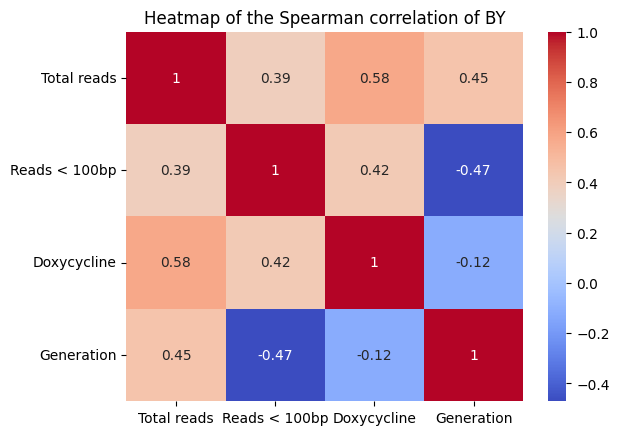

In [44]:
sns.heatmap(nbr_telomere_seqs_df.corr(method="spearman"), 
            annot=True, 
            xticklabels=["Total reads", "Reads < 100bp", "Doxycycline", "Generation"],
            yticklabels=["Total reads", "Reads < 100bp", "Doxycycline", "Generation"], 
            cmap="coolwarm")

plt.title("Heatmap of the Spearman correlation of BY")
plt.savefig("donatelo_BY_spearman_correlation_heatmap.png", dpi=450)

In [182]:
from scipy.stats import spearmanr

# H0 : The correlation between the amount of doxycycline and the number of reads containing only telomeric sequences is due to random chance (no correlation).
# H1 : There is a statistically significant correlation between the amount of doxycycline and the number of reads containing only telomeric sequences.

# The test transform the correlation coefficient into a t-value, which is compared to a t-distribution (look a little bit like a bell) to get the p-value.
# Being compared to a distribution means that the t-value is the value of the x-axis of the distribution, 
# and the p-value is the area under the curve of the distribution that is more extreme than the t-value 
# (either in the positive or negative direction, depending on the sign of the correlation coefficient).

# Therefore, the probability that the correlation is random is the p-value here.

corr_coeff, p_value = spearmanr(nbr_telomere_seqs_df['Doxycycline'], nbr_telomere_seqs_df['Total reads ne contenant que des séquences télomériques'])
t_value = corr_coeff * np.sqrt((len(nbr_telomere_seqs_df) - 2) / (1 - corr_coeff**2))
print(t_value)
print(f"Coefficient : {corr_coeff}, P-value : {p_value}")

4.034558199447328
Coefficient : 0.5689950088768163, P-value : 0.0002932488188124099


# Other